In [154]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [155]:
database=['llnl.dat'];

In [156]:
% variables

% amounts
XP=0.15; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [157]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [158]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [159]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [160]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [161]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [162]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [163]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  











Simulation 1. Kinetic step 3.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  











Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  











Simulation 1. Kinetic step 7.                                                  











Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.

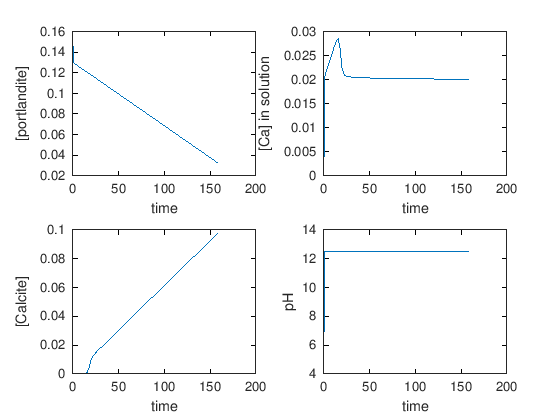

In [164]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [165]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.0	11.70	-0.1805	NaN	0.044 	-0.0288
0.1	11.92	1.5380	1359	1.503 	0.1350
2.0	11.95	0.5828	1736	4.792 	0.1848
24.0	9.36	0.4398	342	1.239 	0.7150
48.1	8.22	1.2568	431	1.373 	1.0982
72.8	8.19	1.2457	437	1.291 	1.0739
95.4	8.20	0.9864	446	1.285 	1.0682
120.7	8.11	0.8884	450	1.249 	1.0379
0.00	6.66	-0.1000	NaN	NaN	0.0144
0.08	11.83	1.9804	1433	3.63225	0.1815
2.00	11.93	2.3287	1919	4.3655	0.2167
23.95	11.95	0.5539	321	1.31853	0.7679
28.55	9.49	0.9993	370	1.4909	1.0164
47.97	8.14	1.4155	415	1.38088	1.1682
71.43	8.11	1.4158	424.00	1.35303	1.1129
99.97	8.13	1.3274	413.00	1.29188	1.0989
144.67	8.15	1.3003	435.00	1.32263	1.0804
-0.03	6.80	-0.0070	NaN	0.07415	0.0266
0	11.78	2.6626	NaN	3.63725	0.1679
0.1	11.89	2.1613	1456	4.83675	0.2158
2	11.94	0.8916	1916	1.41193	0.9079
24	8.63	1.4257	341	1.56245	1.1686
48	8.11	1.4277	400	1.38903	1.1550
72	8.05	1.4758	400	1.3737	1.1511
96	8.08	0.7236	384	1.26313	1.0729
144	8.12	1.3224	419	1.2297	0.9879

];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


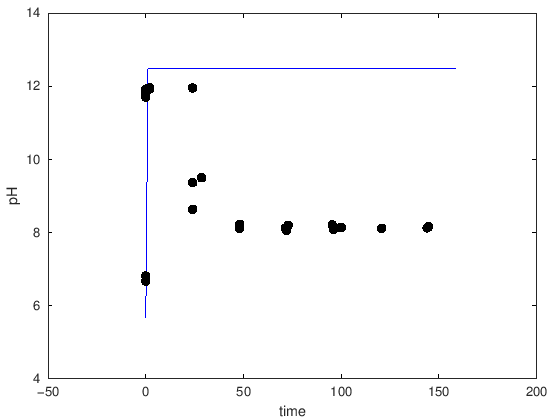

In [166]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

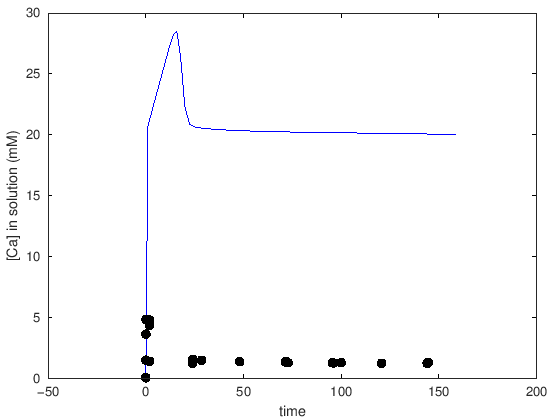

In [167]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

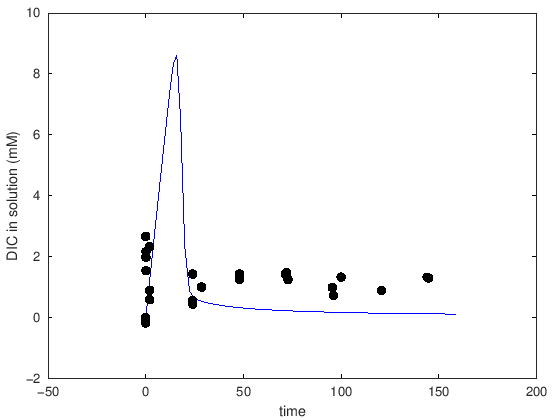

In [168]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

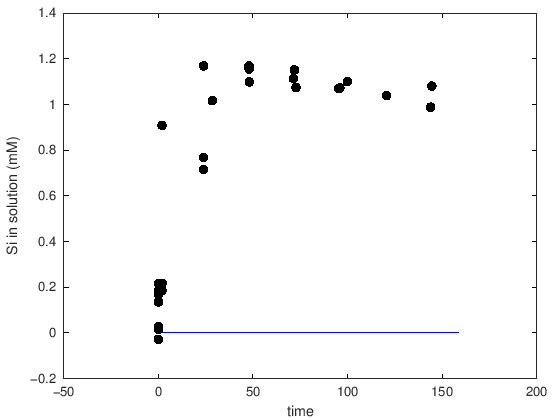

In [169]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

In [ ]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',5)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)		CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
10	0.166666667	299.0825688		0.000055825	3.61391E-05	0.00001968586 	19.7 	236.2 	19.7 
15	0.25	131.1926606		0.000055825	1.58524E-05	0.00003997255 	40.0 	479.7 	59.7 
20	0.333333333	74.31192661		5.49792E-05	8.97936E-06	0.00004599981 	46.0 	552.0 	105.7 
25	0.416666667	51.37614679		0.000054375	6.20795E-06	0.00004816705 	48.2 	578.0 	153.8 
30	0.5	44.03669725		5.42542E-05	5.3211E-06	0.00004893307 	48.9 	587.2 	202.8 
35	0.583333333	44.03669725		5.35292E-05	5.3211E-06	0.00004820807 	48.2 	578.5 	251.0 
40	0.666666667	38.53211009		5.47375E-05	4.65596E-06	0.00005008154 	50.1 	601.0 	301.0 
45	0.75	36.69724771		5.55833E-05	4.43425E-06	0.00005114908 	51.1 	613.8 	352.2 
50	0.833333333	33.02752294		5.47375E-05	3.99083E-06	0.00005074667 	50.7 	609.0 	402.9 
55	0.916666667	33.94495413		5.49792E-05	4.10168E-06	0.00005087748 	50.9 	610.5 	453.8 
60	1	36.69724771		5.59458E-05	4.43425E-06	0.00005151158 	51.5 	618.1 	505.3 
65	1.083333333	46.78899083		5.64292E-05	5.65367E-06	0.00005077550 	50.8 	609.3 	556.1 
70	1.166666667	44.03669725		5.69125E-05	5.3211E-06	0.00005159140 	51.6 	619.1 	607.7 
75	1.25	33.02752294		5.76375E-05	3.99083E-06	0.00005364667 	53.6 	643.8 	661.3 
80	1.333333333	34.86238532		5.75167E-05	4.21254E-06	0.00005330413 	53.3 	639.6 	714.7 
85	1.416666667	36.69724771		0.000057275	4.43425E-06	0.00005284075 	52.8 	634.1 	767.5 
90	1.5	50.4587156		0.0000551	6.09709E-06	0.00004900291 	49.0 	588.0 	816.5 
95	1.583333333	39.44954128		5.52208E-05	4.76682E-06	0.00005045401 	50.5 	605.4 	866.9 
100	1.666666667	49.5412844		5.59458E-05	5.98624E-06	0.00004995959 	50.0 	599.5 	916.9 
105	1.75	37.6146789		0.0000551	4.54511E-06	0.00005055489 	50.6 	606.7 	967.5 
110	1.833333333	43.11926606		5.41333E-05	5.21024E-06	0.00004892309 	48.9 	587.1 	1016.4 
115	1.916666667	43.11926606		5.54625E-05	5.21024E-06	0.00005025226 	50.3 	603.0 	1066.6 
120	2	44.95412844		5.44958E-05	5.43196E-06	0.00004906388 	49.1 	588.8 	1115.7 
125	2.083333333	44.03669725		5.46167E-05	5.3211E-06	0.00004929557 	49.3 	591.5 	1165.0 
130	2.166666667	44.03669725		5.46167E-05	5.3211E-06	0.00004929557 	49.3 	591.5 	1214.3 
135	2.25	41.28440367		5.38917E-05	4.98853E-06	0.00004890313 	48.9 	586.8 	1263.2 
140	2.333333333	39.44954128		5.42542E-05	4.76682E-06	0.00004948735 	49.5 	593.8 	1312.7 
145	2.416666667	38.53211009		5.48583E-05	4.65596E-06	0.00005020237 	50.2 	602.4 	1362.9 
150	2.5	44.03669725		5.54625E-05	5.3211E-06	0.00005014140 	50.1 	601.7 	1413.0 
155	2.583333333	50.4587156		5.54625E-05	6.09709E-06	0.00004936541 	49.4 	592.4 	1462.4 
160	2.666666667	41.28440367		0.0000551	4.98853E-06	0.00005011147 	50.1 	601.3 	1512.5 
165	2.75	44.03669725		5.49792E-05	5.3211E-06	0.00004965807 	49.7 	595.9 	1562.2 
170	2.833333333	41.28440367		5.48583E-05	4.98853E-06	0.00004986980 	49.9 	598.4 	1612.0 
175	2.916666667	45.87155963		5.57042E-05	5.54281E-06	0.00005016135 	50.2 	601.9 	1662.2 
180	3	98.16513761		5.60667E-05	1.18616E-05	0.00004420505 	44.2 	530.5 	1706.4 
185	3.083333333	173.3944954		5.57042E-05	2.09518E-05	0.00003475233 	34.8 	417.0 	1741.2 
190	3.166666667	93.57798165		5.60667E-05	1.13073E-05	0.00004475933 	44.8 	537.1 	1785.9 
195	3.25	58.71559633		5.90875E-05	7.0948E-06	0.00005199270 	52.0 	623.9 	1837.9 
200	3.333333333	52.29357798		0.000057275	6.31881E-06	0.00005095619 	51.0 	611.5 	1888.9 
205	3.416666667	54.12844037		5.71542E-05	6.54052E-06	0.00005061365 	50.6 	607.4 	1939.5 
210	3.5	48.62385321		0.00005655	5.87538E-06	0.00005067462 	50.7 	608.1 	1990.1 
215	3.583333333	45.87155963		5.60667E-05	5.54281E-06	0.00005052385 	50.5 	606.3 	2040.7 
220	3.666666667	44.03669725		5.60667E-05	5.3211E-06	0.00005074557 	50.7 	608.9 	2091.4 
225	3.75	45.87155963		5.69125E-05	5.54281E-06	0.00005136969 	51.4 	616.4 	2142.8 
230	3.833333333	44.95412844		5.53417E-05	5.43196E-06	0.00004990971 	49.9 	598.9 	2192.7 
235	3.916666667	45.87155963		0.0000551	5.54281E-06	0.00004955719 	49.6 	594.7 	2242.3 
240	4	48.62385321		5.60667E-05	5.87538E-06	0.00005019128 	50.2 	602.3 	2292.4 
245	4.083333333	54.12844037		5.70333E-05	6.54052E-06	0.00005049281 	50.5 	605.9 	2342.9 
250	4.166666667	39.44954128		5.76375E-05	4.76682E-06	0.00005287068 	52.9 	634.4 	2395.8 
255	4.25	47.70642202		5.69125E-05	5.76453E-06	0.00005114797 	51.1 	613.8 	2447.0 
260	4.333333333	50.4587156		5.63083E-05	6.09709E-06	0.00005021124 	50.2 	602.5 	2497.2 
265	4.416666667	52.29357798		5.66708E-05	6.31881E-06	0.00005035203 	50.4 	604.2 	2547.5 
270	4.5	48.62385321		5.75167E-05	5.87538E-06	0.00005164128 	51.6 	619.7 	2599.2 
275	4.583333333	46.78899083		5.70333E-05	5.65367E-06	0.00005137966 	51.4 	616.6 	2650.5 
280	4.666666667	54.12844037		5.64292E-05	6.54052E-06	0.00004988865 	49.9 	598.7 	2700.4 
285	4.75	50.4587156		5.67917E-05	6.09709E-06	0.00005069457 	50.7 	608.3 	2751.1 
290	4.833333333	45.87155963		0.000055825	5.54281E-06	0.00005028219 	50.3 	603.4 	2801.4 
295	4.916666667	47.70642202		0.000055825	5.76453E-06	0.00005006047 	50.1 	600.7 	2851.5 
300	5	50.4587156		5.60667E-05	6.09709E-06	0.00004996957 	50.0 	599.6 	2901.4 
305	5.083333333	55.96330275		5.57042E-05	6.76223E-06	0.00004894193 	48.9 	587.3 	2950.4 
310	5.166666667	54.12844037		5.46167E-05	6.54052E-06	0.00004807615 	48.1 	576.9 	2998.5 
315	5.25	46.78899083		0.000054375	5.65367E-06	0.00004872133 	48.7 	584.7 	3047.2 
320	5.333333333	56.88073394		5.32875E-05	6.87309E-06	0.00004641441 	46.4 	557.0 	3093.6 
325	5.416666667	48.62385321		5.31667E-05	5.87538E-06	0.00004729128 	47.3 	567.5 	3140.9 
330	5.5	49.5412844		5.11125E-05	5.98624E-06	0.00004512626 	45.1 	541.5 	3186.0 
335	5.583333333	51.37614679		5.06292E-05	6.20795E-06	0.00004442122 	44.4 	533.1 	3230.4 
340	5.666666667	50.4587156		4.91792E-05	6.09709E-06	0.00004308207 	43.1 	517.0 	3273.5 
345	5.75	44.03669725		4.88167E-05	5.3211E-06	0.00004349557 	43.5 	521.9 	3317.0 
350	5.833333333	48.62385321		4.90583E-05	5.87538E-06	0.00004318295 	43.2 	518.2 	3360.2 
355	5.916666667	41.28440367		4.83333E-05	4.98853E-06	0.00004334480 	43.3 	520.1 	3403.5 
360	6	49.5412844		4.86958E-05	5.98624E-06	0.00004270959 	42.7 	512.5 	3446.2 
365	6.083333333	55.96330275		4.91792E-05	6.76223E-06	0.00004241693 	42.4 	509.0 	3488.7 
370	6.166666667	59.63302752		4.94208E-05	7.20566E-06	0.00004221518 	42.2 	506.6 	3530.9 
375	6.25	49.5412844		4.95417E-05	5.98624E-06	0.00004355543 	43.6 	522.7 	3574.4 
380	6.333333333	57.79816514		4.91792E-05	6.98394E-06	0.00004219522 	42.2 	506.3 	3616.6 
385	6.416666667	56.88073394		4.96625E-05	6.87309E-06	0.00004278941 	42.8 	513.5 	3659.4 
390	6.5	57.79816514		4.91792E-05	6.98394E-06	0.00004219522 	42.2 	506.3 	3701.6 
395	6.583333333	51.37614679		4.89375E-05	6.20795E-06	0.00004272955 	42.7 	512.8 	3744.3 
400	6.666666667	69.72477064		4.89375E-05	8.42508E-06	0.00004051242 	40.5 	486.1 	3784.9 
405	6.75	51.37614679		0.0000493	6.20795E-06	0.00004309205 	43.1 	517.1 	3827.9 
410	6.833333333	49.5412844		4.89375E-05	5.98624E-06	0.00004295126 	43.0 	515.4 	3870.9 
415	6.916666667	58.71559633		4.86958E-05	7.0948E-06	0.00004160103 	41.6 	499.2 	3912.5 
420	7	52.29357798		4.88167E-05	6.31881E-06	0.00004249786 	42.5 	510.0 	3955.0 
425	7.083333333	58.71559633		4.88167E-05	7.0948E-06	0.00004172187 	41.7 	500.7 	3996.7 
430	7.166666667	49.5412844		4.94208E-05	5.98624E-06	0.00004343459 	43.4 	521.2 	4040.2 
435	7.25	55.04587156		4.97833E-05	6.65138E-06	0.00004313196 	43.1 	517.6 	4083.3 
440	7.333333333	54.12844037		4.96625E-05	6.54052E-06	0.00004312198 	43.1 	517.5 	4126.4 
445	7.416666667	49.5412844		4.91792E-05	5.98624E-06	0.00004319293 	43.2 	518.3 	4169.6 
450	7.5	55.96330275		4.88167E-05	6.76223E-06	0.00004205443 	42.1 	504.7 	4211.7 
455	7.583333333	63.30275229		4.83333E-05	7.64908E-06	0.00004068425 	40.7 	488.2 	4252.3 
460	7.666666667	53.21100917		4.86958E-05	6.42966E-06	0.00004226617 	42.3 	507.2 	4294.6 
465	7.75	63.30275229		4.89375E-05	7.64908E-06	0.00004128842 	41.3 	495.5 	4335.9 
470	7.833333333	64.22018349		0.0000493	7.75994E-06	0.00004154006 	41.5 	498.5 	4377.4 
475	7.916666667	53.21100917		4.90583E-05	6.42966E-06	0.00004262867 	42.6 	511.5 	4420.1 
480	8	56.88073394		4.89375E-05	6.87309E-06	0.00004206441 	42.1 	504.8 	4462.1 
485	8.083333333	59.63302752		4.88167E-05	7.20566E-06	0.00004161101 	41.6 	499.3 	4503.7 
490	8.166666667	54.12844037		4.86958E-05	6.54052E-06	0.00004215531 	42.2 	505.9 	4545.9 
495	8.25	52.29357798		4.88167E-05	6.31881E-06	0.00004249786 	42.5 	510.0 	4588.4 
500	8.333333333	55.96330275		4.84542E-05	6.76223E-06	0.00004169193 	41.7 	500.3 	4630.1 
505	8.416666667	60.55045872		0.000048575	7.31651E-06	0.00004125849 	41.3 	495.1 	4671.3 
510	8.5	60.55045872		4.95417E-05	7.31651E-06	0.00004222515 	42.2 	506.7 	4713.6 
515	8.583333333	57.79816514		4.95417E-05	6.98394E-06	0.00004255772 	42.6 	510.7 	4756.1 
520	8.666666667	66.97247706		0.0000493	8.09251E-06	0.00004120749 	41.2 	494.5 	4797.3 
525	8.75	59.63302752		4.89375E-05	7.20566E-06	0.00004173184 	41.7 	500.8 	4839.1 
530	8.833333333	62.3853211		0.000048575	7.53823E-06	0.00004103677 	41.0 	492.4 	4880.1 
535	8.916666667	66.05504587		4.86958E-05	7.98165E-06	0.00004071418 	40.7 	488.6 	4920.8 
540	9	57.79816514		4.88167E-05	6.98394E-06	0.00004183272 	41.8 	502.0 	4962.6 
545	9.083333333	63.30275229		4.86958E-05	7.64908E-06	0.00004104675 	41.0 	492.6 	5003.7 
550	9.166666667	65.13761468		4.88167E-05	7.8708E-06	0.00004094587 	40.9 	491.4 	5044.6 
555	9.25	58.71559633		4.83333E-05	7.0948E-06	0.00004123853 	41.2 	494.9 	5085.9 
560	9.333333333	66.97247706		4.83333E-05	8.09251E-06	0.00004024083 	40.2 	482.9 	5126.1 
565	9.416666667	63.30275229		4.91792E-05	7.64908E-06	0.00004153008 	41.5 	498.4 	5167.6 
570	9.5	58.71559633		4.88167E-05	7.0948E-06	0.00004172187 	41.7 	500.7 	5209.4 
575	9.583333333	69.72477064		0.0000493	8.42508E-06	0.00004087492 	40.9 	490.5 	5250.2 
580	9.666666667	63.30275229		4.88167E-05	7.64908E-06	0.00004116758 	41.2 	494.0 	5291.4 
585	9.75	54.12844037		4.97833E-05	6.54052E-06	0.00004324281 	43.2 	518.9 	5334.7 
590	9.833333333	59.63302752		4.91792E-05	7.20566E-06	0.00004197351 	42.0 	503.7 	5376.6 
595	9.916666667	67.88990826		4.94208E-05	8.20336E-06	0.00004121747 	41.2 	494.6 	5417.8 
600	10	62.3853211		4.89375E-05	7.53823E-06	0.00004139927 	41.4 	496.8 	5459.2 
605	10.08333333	66.05504587		4.89375E-05	7.98165E-06	0.00004095585 	41.0 	491.5 	5500.2 
610	10.16666667	62.3853211		4.86958E-05	7.53823E-06	0.00004115761 	41.2 	493.9 	5541.4 
615	10.25	64.22018349		4.86958E-05	7.75994E-06	0.00004093589 	40.9 	491.2 	5582.3 
620	10.33333333	71.55963303		0.000048575	8.64679E-06	0.00003992821 	39.9 	479.1 	5622.2 
625	10.41666667	71.55963303		0.000048575	8.64679E-06	0.00003992821 	39.9 	479.1 	5662.2 
630	10.5	69.72477064		4.95417E-05	8.42508E-06	0.00004111659 	41.1 	493.4 	5703.3 
635	10.58333333	83.48623853		0.0000493	1.00879E-05	0.00003921208 	39.2 	470.5 	5742.5 
640	10.66666667	72.47706422		0.0000493	8.75765E-06	0.00004054235 	40.5 	486.5 	5783.0 
645	10.75	63.30275229		4.91792E-05	7.64908E-06	0.00004153008 	41.5 	498.4 	5824.6 
650	10.83333333	63.30275229		4.91792E-05	7.64908E-06	0.00004153008 	41.5 	498.4 	5866.1 
655	10.91666667	64.22018349		4.83333E-05	7.75994E-06	0.00004057339 	40.6 	486.9 	5906.7 
660	11	68.80733945		4.89375E-05	8.31422E-06	0.00004062328 	40.6 	487.5 	5947.3 
665	11.08333333	76.14678899		4.95417E-05	9.20107E-06	0.00004034060 	40.3 	484.1 	5987.6 
670	11.16666667	61.46788991		4.89375E-05	7.42737E-06	0.00004151013 	41.5 	498.1 	6029.1 
675	11.25	73.39449541		4.89375E-05	8.8685E-06	0.00004006900 	40.1 	480.8 	6069.2 
680	11.33333333	68.80733945		4.96625E-05	8.31422E-06	0.00004134828 	41.3 	496.2 	6110.5 
685	11.41666667	77.06422018		4.90583E-05	9.31193E-06	0.00003974641 	39.7 	477.0 	6150.3 
690	11.5	73.39449541		4.88167E-05	8.8685E-06	0.00003994817 	39.9 	479.4 	6190.2 
695	11.58333333	71.55963303		4.86958E-05	8.64679E-06	0.00004004904 	40.0 	480.6 	6230.3 
700	11.66666667	69.72477064		4.84542E-05	8.42508E-06	0.00004002909 	40.0 	480.3 	6270.3 
705	11.75	69.72477064		4.90583E-05	8.42508E-06	0.00004063326 	40.6 	487.6 	6311.0 
710	11.83333333	67.88990826		0.000048575	8.20336E-06	0.00004037164 	40.4 	484.5 	6351.3 
715	11.91666667	70.64220183		4.95417E-05	8.53593E-06	0.00004100573 	41.0 	492.1 	6392.3 
720	12	73.39449541		4.88167E-05	8.8685E-06	0.00003994817 	39.9 	479.4 	6432.3 
725	12.08333333	65.13761468		4.95417E-05	7.8708E-06	0.00004167087 	41.7 	500.1 	6473.9 
730	12.16666667	69.72477064		4.91792E-05	8.42508E-06	0.00004075409 	40.8 	489.0 	6514.7 
735	12.25	71.55963303		4.99042E-05	8.64679E-06	0.00004125738 	41.3 	495.1 	6556.0 
740	12.33333333	72.47706422		5.05083E-05	8.75765E-06	0.00004175069 	41.8 	501.0 	6597.7 
745	12.41666667	77.06422018		5.02667E-05	9.31193E-06	0.00004095474 	41.0 	491.5 	6638.7 
750	12.5	66.97247706		5.06292E-05	8.09251E-06	0.00004253666 	42.5 	510.4 	6681.2 
755	12.58333333	76.14678899		5.02667E-05	9.20107E-06	0.00004106560 	41.1 	492.8 	6722.3 
760	12.66666667	71.55963303		0.000050025	8.64679E-06	0.00004137821 	41.4 	496.5 	6763.6 
765	12.75	82.56880734		4.99042E-05	9.97706E-06	0.00003992710 	39.9 	479.1 	6803.6 
770	12.83333333	73.39449541		4.99042E-05	8.8685E-06	0.00004103567 	41.0 	492.4 	6844.6 
775	12.91666667	83.48623853		5.02667E-05	1.00879E-05	0.00004017875 	40.2 	482.1 	6884.8 
780	13	77.98165138		0.00005075	9.42278E-06	0.00004132722 	41.3 	495.9 	6926.1 
785	13.08333333	82.56880734		5.05083E-05	9.97706E-06	0.00004053127 	40.5 	486.4 	6966.6 
790	13.16666667	78.89908257		5.03875E-05	9.53364E-06	0.00004085386 	40.9 	490.2 	7007.5 
795	13.25	74.31192661		0.000050025	8.97936E-06	0.00004104564 	41.0 	492.5 	7048.5 
800	13.33333333	78.89908257		0.00005075	9.53364E-06	0.00004121636 	41.2 	494.6 	7089.8 
805	13.41666667	79.81651376		5.05083E-05	9.6445E-06	0.00004086384 	40.9 	490.4 	7130.6 
810	13.5	78.89908257		0.000050025	9.53364E-06	0.00004049136 	40.5 	485.9 	7171.1 
815	13.58333333	70.64220183		5.03875E-05	8.53593E-06	0.00004185157 	41.9 	502.2 	7213.0 
820	13.66666667	66.05504587		5.05083E-05	7.98165E-06	0.00004252668 	42.5 	510.3 	7255.5 
825	13.75	81.65137615		4.91792E-05	9.86621E-06	0.00003931296 	39.3 	471.8 	7294.8 
830	13.83333333	78.89908257		5.01458E-05	9.53364E-06	0.00004061219 	40.6 	487.3 	7335.4 
835	13.91666667	83.48623853		5.03875E-05	1.00879E-05	0.00004029958 	40.3 	483.6 	7375.7 
840	14	78.89908257		4.99042E-05	9.53364E-06	0.00004037053 	40.4 	484.4 	7416.1 
845	14.08333333	80.73394495		5.02667E-05	9.75535E-06	0.00004051131 	40.5 	486.1 	7456.6 
850	14.16666667	88.99082569		5.05083E-05	1.07531E-05	0.00003975528 	39.8 	477.1 	7496.4 
855	14.25	82.56880734		0.000050025	9.97706E-06	0.00004004794 	40.0 	480.6 	7536.4 
860	14.33333333	84.40366972		5.02667E-05	1.01988E-05	0.00004006789 	40.1 	480.8 	7576.5 
865	14.41666667	81.65137615		0.000050025	9.86621E-06	0.00004015879 	40.2 	481.9 	7616.6 
870	14.5	83.48623853		0.00005075	1.00879E-05	0.00004066208 	40.7 	487.9 	7657.3 
875	14.58333333	87.1559633		5.01458E-05	1.05313E-05	0.00003961449 	39.6 	475.4 	7696.9 
880	14.66666667	93.57798165		4.97833E-05	1.13073E-05	0.00003847599 	38.5 	461.7 	7735.4 
885	14.75	75.2293578		4.96625E-05	9.09021E-06	0.00004057229 	40.6 	486.9 	7776.0 
890	14.83333333	81.65137615		4.94208E-05	9.86621E-06	0.00003955463 	39.6 	474.7 	7815.5 
895	14.91666667	85.32110092		5.03875E-05	1.03096E-05	0.00004007787 	40.1 	480.9 	7855.6 
900	15	77.06422018		4.97833E-05	9.31193E-06	0.00004047141 	40.5 	485.7 	7896.1 
905	15.08333333	87.1559633		4.91792E-05	1.05313E-05	0.00003864782 	38.6 	463.8 	7934.7 
910	15.16666667	77.06422018		4.97833E-05	9.31193E-06	0.00004047141 	40.5 	485.7 	7975.2 
915	15.25	88.99082569		5.02667E-05	1.07531E-05	0.00003951361 	39.5 	474.2 	8014.7 
920	15.33333333	93.57798165		4.96625E-05	1.13073E-05	0.00003835516 	38.4 	460.3 	8053.0 
925	15.41666667	88.99082569		4.99042E-05	1.07531E-05	0.00003915111 	39.2 	469.8 	8092.2 
930	15.5	89.90825688		0.0000493	1.08639E-05	0.00003843609 	38.4 	461.2 	8130.6 
935	15.58333333	82.56880734		4.99042E-05	9.97706E-06	0.00003992710 	39.9 	479.1 	8170.6 
940	15.66666667	93.57798165		4.95417E-05	1.13073E-05	0.00003823433 	38.2 	458.8 	8208.8 
945	15.75	86.23853211		0.0000493	1.04205E-05	0.00003887951 	38.9 	466.6 	8247.7 
950	15.83333333	83.48623853		4.96625E-05	1.00879E-05	0.00003957458 	39.6 	474.9 	8287.3 
955	15.91666667	85.32110092		4.97833E-05	1.03096E-05	0.00003947370 	39.5 	473.7 	8326.7 
960	16	81.65137615		4.97833E-05	9.86621E-06	0.00003991713 	39.9 	479.0 	8366.6 
965	16.08333333	81.65137615		4.95417E-05	9.86621E-06	0.00003967546 	39.7 	476.1 	8406.3 
970	16.16666667	86.23853211		0.0000493	1.04205E-05	0.00003887951 	38.9 	466.6 	8445.2 
975	16.25	77.06422018		4.94208E-05	9.31193E-06	0.00004010891 	40.1 	481.3 	8485.3 
980	16.33333333	90.82568807		0.0000493	1.09748E-05	0.00003832523 	38.3 	459.9 	8523.6 
985	16.41666667	85.32110092		4.95417E-05	1.03096E-05	0.00003923203 	39.2 	470.8 	8562.9 
990	16.5	91.74311927		0.0000493	1.10856E-05	0.00003821437 	38.2 	458.6 	8601.1 
995	16.58333333	82.56880734		4.90583E-05	9.97706E-06	0.00003908127 	39.1 	469.0 	8640.2 
1000	16.66666667	83.48623853		4.95417E-05	1.00879E-05	0.00003945375 	39.5 	473.4 	8679.6 
1005	16.75	86.23853211		4.95417E-05	1.04205E-05	0.00003912118 	39.1 	469.5 	8718.7 
1010	16.83333333	79.81651376		4.94208E-05	9.6445E-06	0.00003977634 	39.8 	477.3 	8758.5 
1015	16.91666667	83.48623853		4.95417E-05	1.00879E-05	0.00003945375 	39.5 	473.4 	8798.0 
1020	17	88.99082569		4.97833E-05	1.07531E-05	0.00003903028 	39.0 	468.4 	8837.0 
1025	17.08333333	96.33027523		4.99042E-05	1.16399E-05	0.00003826426 	38.3 	459.2 	8875.3 
1030	17.16666667	87.1559633		4.95417E-05	1.05313E-05	0.00003901032 	39.0 	468.1 	8914.3 
1035	17.25	103.6697248		4.90583E-05	1.25268E-05	0.00003653157 	36.5 	438.4 	8950.8 
1040	17.33333333	86.23853211		4.89375E-05	1.04205E-05	0.00003851701 	38.5 	462.2 	8989.3 
1045	17.41666667	91.74311927		4.91792E-05	1.10856E-05	0.00003809354 	38.1 	457.1 	9027.4 
1050	17.5	88.99082569		4.95417E-05	1.07531E-05	0.00003878861 	38.8 	465.5 	9066.2 
1055	17.58333333	84.40366972		4.91792E-05	1.01988E-05	0.00003898039 	39.0 	467.8 	9105.2 
1060	17.66666667	91.74311927		4.90583E-05	1.10856E-05	0.00003797271 	38.0 	455.7 	9143.2 
1065	17.75	94.49541284		4.90583E-05	1.14182E-05	0.00003764014 	37.6 	451.7 	9180.8 
1070	17.83333333	83.48623853		4.90583E-05	1.00879E-05	0.00003897041 	39.0 	467.6 	9219.8 
1075	17.91666667	93.57798165		4.89375E-05	1.13073E-05	0.00003763016 	37.6 	451.6 	9257.4 
1080	18	81.65137615		4.95417E-05	9.86621E-06	0.00003967546 	39.7 	476.1 	9297.1 
1085	18.08333333	87.1559633		4.94208E-05	1.05313E-05	0.00003888949 	38.9 	466.7 	9336.0 
1090	18.16666667	90.82568807		4.97833E-05	1.09748E-05	0.00003880856 	38.8 	465.7 	9374.8 
1095	18.25	97.24770642		4.86958E-05	1.17508E-05	0.00003694507 	36.9 	443.3 	9411.7 
1100	18.33333333	89.90825688		4.96625E-05	1.08639E-05	0.00003879859 	38.8 	465.6 	9450.5 
1105	18.41666667	93.57798165		4.99042E-05	1.13073E-05	0.00003859683 	38.6 	463.2 	9489.1 
1110	18.5	95.41284404		0.0000493	1.15291E-05	0.00003777095 	37.8 	453.3 	9526.9 
1115	18.58333333	96.33027523		4.94208E-05	1.16399E-05	0.00003778093 	37.8 	453.4 	9564.7 
1120	18.66666667	96.33027523		0.0000493	1.16399E-05	0.00003766009 	37.7 	451.9 	9602.3 
1125	18.75	93.57798165		4.94208E-05	1.13073E-05	0.00003811349 	38.1 	457.4 	9640.4 
1130	18.83333333	88.0733945		4.96625E-05	1.06422E-05	0.00003902030 	39.0 	468.2 	9679.5 
1135	18.91666667	81.65137615		4.96625E-05	9.86621E-06	0.00003979629 	39.8 	477.6 	9719.2 
1140	19	99.08256881		4.97833E-05	1.19725E-05	0.00003781086 	37.8 	453.7 	9757.1 
1145	19.08333333	89.90825688		4.97833E-05	1.08639E-05	0.00003891942 	38.9 	467.0 	9796.0 
1150	19.16666667	101.8348624		4.99042E-05	1.2305E-05	0.00003759912 	37.6 	451.2 	9833.6 
1155	19.25	94.49541284		4.99042E-05	1.14182E-05	0.00003848597 	38.5 	461.8 	9872.1 
1160	19.33333333	96.33027523		4.94208E-05	1.16399E-05	0.00003778093 	37.8 	453.4 	9909.8 
1165	19.41666667	95.41284404		4.91792E-05	1.15291E-05	0.00003765011 	37.7 	451.8 	9947.5 
1170	19.5	99.08256881		4.95417E-05	1.19725E-05	0.00003756919 	37.6 	450.8 	9985.1 
1175	19.58333333	99.08256881		4.99042E-05	1.19725E-05	0.00003793169 	37.9 	455.2 	10023.0 
1180	19.66666667	98.16513761		0.000050025	1.18616E-05	0.00003816338 	38.2 	458.0 	10061.2 
1185	19.75	101.8348624		4.95417E-05	1.2305E-05	0.00003723662 	37.2 	446.8 	10098.4 
1190	19.83333333	95.41284404		4.97833E-05	1.15291E-05	0.00003825428 	38.3 	459.1 	10136.7 
1195	19.91666667	97.24770642		4.94208E-05	1.17508E-05	0.00003767007 	37.7 	452.0 	10174.3 
1200	20	95.41284404		4.91792E-05	1.15291E-05	0.00003765011 	37.7 	451.8 	10212.0 
1205	20.08333333	99.08256881		4.90583E-05	1.19725E-05	0.00003708586 	37.1 	445.0 	10249.1 
1210	20.16666667	91.74311927		0.000050025	1.10856E-05	0.00003893937 	38.9 	467.3 	10288.0 
1215	20.25	100		4.94208E-05	1.20833E-05	0.00003733750 	37.3 	448.1 	10325.3 
1220	20.33333333	97.24770642		4.96625E-05	1.17508E-05	0.00003791174 	37.9 	454.9 	10363.2 
1225	20.41666667	106.4220183		4.99042E-05	1.28593E-05	0.00003704484 	37.0 	444.5 	10400.3 
1230	20.5	102.7522936		5.06292E-05	1.24159E-05	0.00003821326 	38.2 	458.6 	10438.5 
1235	20.58333333	102.7522936		5.08708E-05	1.24159E-05	0.00003845493 	38.5 	461.5 	10477.0 
1240	20.66666667	108.2568807		5.18375E-05	1.3081E-05	0.00003875646 	38.8 	465.1 	10515.7 
1245	20.75	102.7522936		5.18375E-05	1.24159E-05	0.00003942160 	39.4 	473.1 	10555.1 
1250	20.83333333	101.8348624		5.11125E-05	1.2305E-05	0.00003880745 	38.8 	465.7 	10593.9 
1255	20.91666667	104.587156		5.17167E-05	1.26376E-05	0.00003907905 	39.1 	468.9 	10633.0 
1260	21	104.587156		5.26833E-05	1.26376E-05	0.00004004572 	40.0 	480.5 	10673.1 
1265	21.08333333	101.8348624		5.31667E-05	1.2305E-05	0.00004086162 	40.9 	490.3 	10713.9 
1270	21.16666667	103.6697248		5.25625E-05	1.25268E-05	0.00004003574 	40.0 	480.4 	10754.0 
1275	21.25	108.2568807		5.31667E-05	1.3081E-05	0.00004008563 	40.1 	481.0 	10794.1 
1280	21.33333333	106.4220183		5.24417E-05	1.28593E-05	0.00003958234 	39.6 	475.0 	10833.6 
1285	21.41666667	103.6697248		5.28042E-05	1.25268E-05	0.00004027741 	40.3 	483.3 	10873.9 
1290	21.5	109.1743119		5.28042E-05	1.31919E-05	0.00003961227 	39.6 	475.3 	10913.5 
1295	21.58333333	101.8348624		0.000052925	1.2305E-05	0.00004061995 	40.6 	487.4 	10954.1 
1300	21.66666667	99.08256881		5.28042E-05	1.19725E-05	0.00004083169 	40.8 	490.0 	10995.0 
1305	21.75	98.16513761		5.24417E-05	1.18616E-05	0.00004058005 	40.6 	487.0 	11035.6 
1310	21.83333333	111.0091743		5.34083E-05	1.34136E-05	0.00003999472 	40.0 	479.9 	11075.6 
1315	21.91666667	105.5045872		5.38917E-05	1.27485E-05	0.00004114320 	41.1 	493.7 	11116.7 
1320	22	102.7522936		5.52208E-05	1.24159E-05	0.00004280493 	42.8 	513.7 	11159.5 
1325	22.08333333	121.1009174		0.0000551	1.4633E-05	0.00004046697 	40.5 	485.6 	11200.0 
1330	22.16666667	114.6788991		5.48583E-05	1.3857E-05	0.00004100130 	41.0 	492.0 	11241.0 
1335	22.25	110.0917431		5.49792E-05	1.33028E-05	0.00004167641 	41.7 	500.1 	11282.6 
1340	22.33333333	106.4220183		5.49792E-05	1.28593E-05	0.00004211984 	42.1 	505.4 	11324.8 
1345	22.41666667	105.5045872		5.32875E-05	1.27485E-05	0.00004053903 	40.5 	486.5 	11365.3 
1350	22.5	101.8348624		0.00005365	1.2305E-05	0.00004134495 	41.3 	496.1 	11406.6 
1355	22.58333333	105.5045872		5.35292E-05	1.27485E-05	0.00004078070 	40.8 	489.4 	11447.4 
1360	22.66666667	120.1834862		5.32875E-05	1.45222E-05	0.00003876533 	38.8 	465.2 	11486.2 
1365	22.75	114.6788991		5.31667E-05	1.3857E-05	0.00003930963 	39.3 	471.7 	11525.5 
1370	22.83333333	115.5963303		0.000052925	1.39679E-05	0.00003895711 	39.0 	467.5 	11564.5 
1375	22.91666667	105.5045872		5.35292E-05	1.27485E-05	0.00004078070 	40.8 	489.4 	11605.2 
1380	23	117.4311927		0.00005365	1.41896E-05	0.00003946040 	39.5 	473.5 	11644.7 
1385	23.08333333	105.5045872		5.35292E-05	1.27485E-05	0.00004078070 	40.8 	489.4 	11685.5 
1390	23.16666667	118.3486239		5.32875E-05	1.43005E-05	0.00003898704 	39.0 	467.8 	11724.5 
1395	23.25	111.9266055		5.31667E-05	1.35245E-05	0.00003964220 	39.6 	475.7 	11764.1 
1400	23.33333333	117.4311927		0.000052925	1.41896E-05	0.00003873540 	38.7 	464.8 	11802.8 
1405	23.41666667	110.0917431		5.35292E-05	1.33028E-05	0.00004022641 	40.2 	482.7 	11843.1 
1410	23.5	116.5137615		5.30458E-05	1.40787E-05	0.00003896709 	39.0 	467.6 	11882.0 
1415	23.58333333	113.7614679		5.23208E-05	1.37462E-05	0.00003857466 	38.6 	462.9 	11920.6 
1420	23.66666667	121.1009174		5.37708E-05	1.4633E-05	0.00003913781 	39.1 	469.7 	11959.8 
1425	23.75	127.5229358		5.54625E-05	1.5409E-05	0.00004005348 	40.1 	480.6 	11999.8 
1430	23.83333333	120.1834862		5.46167E-05	1.45222E-05	0.00004009450 	40.1 	481.1 	12039.9 
1435	23.91666667	121.1009174		0.000054375	1.4633E-05	0.00003974197 	39.7 	476.9 	12079.6 
1440	24	132.1100917		5.41333E-05	1.59633E-05	0.00003817003 	38.2 	458.0 	12117.8 
1445	24.08333333	117.4311927		5.40125E-05	1.41896E-05	0.00003982290 	39.8 	477.9 	12157.6 
1450	24.16666667	128.440367		0.000054375	1.55199E-05	0.00003885512 	38.9 	466.3 	12196.5 
1455	24.25	139.4495413		5.41333E-05	1.68502E-05	0.00003728318 	37.3 	447.4 	12233.8 
1460	24.33333333	133.9449541		0.000054375	1.6185E-05	0.00003818998 	38.2 	458.3 	12272.0 
1465	24.41666667	133.9449541		5.47375E-05	1.6185E-05	0.00003855248 	38.6 	462.6 	12310.5 
1470	24.5	134.8623853		5.44958E-05	1.62959E-05	0.00003819996 	38.2 	458.4 	12348.7 
1475	24.58333333	132.1100917		5.49792E-05	1.59633E-05	0.00003901586 	39.0 	468.2 	12387.7 
1480	24.66666667	127.5229358		5.40125E-05	1.5409E-05	0.00003860348 	38.6 	463.2 	12426.3 
1485	24.75	133.9449541		5.41333E-05	1.6185E-05	0.00003794832 	37.9 	455.4 	12464.3 
1490	24.83333333	144.9541284		0.00005365	1.75153E-05	0.00003613471 	36.1 	433.6 	12500.4 
1495	24.91666667	133.9449541		0.000052925	1.6185E-05	0.00003673998 	36.7 	440.9 	12537.2 
1500	25	149.5412844		5.32875E-05	1.80696E-05	0.00003521793 	35.2 	422.6 	12572.4 
1505	25.08333333	145.8715596		5.26833E-05	1.76261E-05	0.00003505719 	35.1 	420.7 	12607.4 
1510	25.16666667	149.5412844		5.25625E-05	1.80696E-05	0.00003449293 	34.5 	413.9 	12641.9 
1515	25.25	154.1284404		0.000052925	1.86239E-05	0.00003430115 	34.3 	411.6 	12676.2 
1520	25.33333333	155.9633028		5.26833E-05	1.88456E-05	0.00003383777 	33.8 	406.1 	12710.1 
1525	25.41666667	159.6330275		5.38917E-05	1.9289E-05	0.00003460268 	34.6 	415.2 	12744.7 
1530	25.5	158.7155963		5.41333E-05	1.91781E-05	0.00003495520 	35.0 	419.5 	12779.6 
1535	25.58333333	160.5504587		5.42542E-05	1.93998E-05	0.00003485432 	34.9 	418.3 	12814.5 
1540	25.66666667	166.0550459		5.40125E-05	2.0065E-05	0.00003394752 	33.9 	407.4 	12848.4 
1545	25.75	167.8899083		0.000054375	2.02867E-05	0.00003408830 	34.1 	409.1 	12882.5 
1550	25.83333333	172.4770642		5.35292E-05	2.0841E-05	0.00003268819 	32.7 	392.3 	12915.2 
1555	25.91666667	181.6513761		5.44958E-05	2.19495E-05	0.00003254629 	32.5 	390.6 	12947.7 
1560	26	183.4862385		5.41333E-05	2.21713E-05	0.00003196208 	32.0 	383.5 	12979.7 
1565	26.08333333	178.8990826		5.34083E-05	2.1617E-05	0.00003179136 	31.8 	381.5 	13011.5 
1570	26.16666667	192.6605505		0.000052925	2.32798E-05	0.00002964518 	29.6 	355.7 	13041.1 
1575	26.25	196.3302752		0.000052925	2.37232E-05	0.00002920176 	29.2 	350.4 	13070.3 
1580	26.33333333	204.587156		5.28042E-05	2.47209E-05	0.00002808322 	28.1 	337.0 	13098.4 
1585	26.41666667	201.8348624		5.35292E-05	2.43884E-05	0.00002914079 	29.1 	349.7 	13127.6 
1590	26.5	217.4311927		5.47375E-05	2.62729E-05	0.00002846456 	28.5 	341.6 	13156.0 
1595	26.58333333	229.3577982		5.55833E-05	2.77141E-05	0.00002786927 	27.9 	334.4 	13183.9 
1600	26.66666667	217.4311927		0.00005655	2.62729E-05	0.00003027706 	30.3 	363.3 	13214.2 
1605	26.75	225.6880734		5.76375E-05	2.72706E-05	0.00003036686 	30.4 	364.4 	13244.5 
1610	26.83333333	237.6146789		0.000060175	2.87118E-05	0.00003146323 	31.5 	377.6 	13276.0 
1615	26.91666667	245.8715596		0.0000609	2.97095E-05	0.00003119052 	31.2 	374.3 	13307.2 
1620	27	243.1192661		6.21083E-05	2.93769E-05	0.00003273142 	32.7 	392.8 	13339.9 
1625	27.08333333	246.7889908		6.15042E-05	2.98203E-05	0.00003168383 	31.7 	380.2 	13371.6 
1630	27.16666667	255.9633028		6.13833E-05	3.09289E-05	0.00003045443 	30.5 	365.5 	13402.1 
1635	27.25	256.8807339		6.46458E-05	3.10398E-05	0.00003360608 	33.6 	403.3 	13435.7 
1640	27.33333333	270.6422018		6.50083E-05	3.27026E-05	0.00003230573 	32.3 	387.7 	13468.0 
1645	27.41666667	277.9816514		6.48875E-05	3.35894E-05	0.00003129805 	31.3 	375.6 	13499.3 
1650	27.5	277.0642202		0.0000638	3.34786E-05	0.00003032141 	30.3 	363.9 	13529.6 
1655	27.58333333	287.1559633		0.0000638	3.4698E-05	0.00002910199 	29.1 	349.2 	13558.7 
1660	27.66666667	286.2385321		6.39208E-05	3.45872E-05	0.00002933368 	29.3 	352.0 	13588.0 
1665	27.75	295.412844		6.47667E-05	3.56957E-05	0.00002907095 	29.1 	348.9 	13617.1 
1670	27.83333333	300		6.56125E-05	0.00003625	0.00002936250 	29.4 	352.4 	13646.5 
1675	27.91666667	299.0825688		6.51292E-05	3.61391E-05	0.00002899002 	29.0 	347.9 	13675.5 
1680	28	305.5045872		6.47667E-05	3.69151E-05	0.00002785153 	27.9 	334.2 	13703.3 
1685	28.08333333	302.7522936		6.29542E-05	3.65826E-05	0.00002637160 	26.4 	316.5 	13729.7 
1690	28.16666667	317.4311927		6.29542E-05	3.83563E-05	0.00002459790 	24.6 	295.2 	13754.3 
1695	28.25	310.0917431		6.17458E-05	3.74694E-05	0.00002427641 	24.3 	291.3 	13778.6 
1700	28.33333333	322.9357798		0.000060175	3.90214E-05	0.00002115359 	21.2 	253.8 	13799.7 
1705	28.41666667	334.8623853		5.96917E-05	4.04625E-05	0.00001922913 	19.2 	230.7 	13818.9 
1710	28.5	331.1926606		5.98125E-05	4.00191E-05	0.00001979339 	19.8 	237.5 	13838.7 
1715	28.58333333	340.3669725		0.000060175	4.11277E-05	0.00001904732 	19.0 	228.6 	13857.8 
1720	28.66666667	345.8715596		6.05375E-05	4.17928E-05	0.00001874469 	18.7 	224.9 	13876.5 
1725	28.75	345.8715596		0.0000609	4.17928E-05	0.00001910719 	19.1 	229.3 	13895.6 
1730	28.83333333	347.706422		6.07792E-05	4.20145E-05	0.00001876464 	18.8 	225.2 	13914.4 
1735	28.91666667	350.4587156		6.00542E-05	4.23471E-05	0.00001770707 	17.7 	212.5 	13932.1 
1740	29	357.7981651		6.00542E-05	4.32339E-05	0.00001682022 	16.8 	201.8 	13948.9 
1745	29.08333333	360.5504587		5.99333E-05	4.35665E-05	0.00001636682 	16.4 	196.4 	13965.3 
1750	29.16666667	365.1376147		5.96917E-05	4.41208E-05	0.00001557087 	15.6 	186.9 	13980.9 
1755	29.25	365.1376147		0.000060175	4.41208E-05	0.00001605420 	16.1 	192.7 	13996.9 
1760	29.33333333	362.3853211		5.96917E-05	4.37882E-05	0.00001590344 	15.9 	190.8 	14012.8 
1765	29.41666667	356.8807339		6.06583E-05	4.31231E-05	0.00001753524 	17.5 	210.4 	14030.4 
1770	29.5	366.0550459		5.89667E-05	4.42317E-05	0.00001473502 	14.7 	176.8 	14045.1 
1775	29.58333333	355.9633028		5.96917E-05	4.30122E-05	0.00001667943 	16.7 	200.2 	14061.8 
1780	29.66666667	361.4678899		5.75167E-05	4.36774E-05	0.00001383930 	13.8 	166.1 	14075.6 
1785	29.75	362.3853211		5.35292E-05	4.37882E-05	0.00000974094 	9.7 	116.9 	14085.4 
1790	29.83333333	364.2201835		0.000052925	4.40099E-05	0.00000891506 	8.9 	107.0 	14094.3 
1795	29.91666667	368.8073394		5.15958E-05	4.45642E-05	0.00000703161 	7.0 	84.4 	14101.3 
1800	30	370.6422018		5.12333E-05	4.47859E-05	0.00000644740 	6.4 	77.4 	14107.7 
1805	30.08333333	368.8073394		5.08708E-05	4.45642E-05	0.00000630661 	6.3 	75.7 	14114.1 
1810	30.16666667	375.2293578		5.06292E-05	4.53402E-05	0.00000528895 	5.3 	63.5 	14119.3 
1815	30.25	376.146789		0.00005075	4.54511E-05	0.00000529893 	5.3 	63.6 	14124.6 
1820	30.33333333	375.2293578		5.09917E-05	4.53402E-05	0.00000565145 	5.7 	67.8 	14130.3 
1825	30.41666667	373.3944954		5.09917E-05	4.51185E-05	0.00000587317 	5.9 	70.5 	14136.2 
1830	30.5	374.3119266		5.11125E-05	4.52294E-05	0.00000588314 	5.9 	70.6 	14142.0 
1835	30.58333333	388.0733945		0.00005075	4.68922E-05	0.00000385780 	3.9 	46.3 	14145.9 
1840	30.66666667	381.6513761		5.11125E-05	4.61162E-05	0.00000499629 	5.0 	60.0 	14150.9 
1845	30.75	388.0733945		5.12333E-05	4.68922E-05	0.00000434113 	4.3 	52.1 	14155.2 
1850	30.83333333	383.4862385		5.12333E-05	4.63379E-05	0.00000489541 	4.9 	58.7 	14160.1 
1855	30.91666667	385.3211009		5.09917E-05	4.65596E-05	0.00000443203 	4.4 	53.2 	14164.6 
1860	31	389.9082569		5.13542E-05	4.71139E-05	0.00000424025 	4.2 	50.9 	14168.8 
1865	31.08333333	382.5688073		5.11125E-05	4.62271E-05	0.00000488544 	4.9 	58.6 	14173.7 
1870	31.16666667	393.5779817		5.15958E-05	4.75573E-05	0.00000403849 	4.0 	48.5 	14177.7 
1875	31.25	393.5779817		5.08708E-05	4.75573E-05	0.00000331349 	3.3 	39.8 	14181.0 
1880	31.33333333	398.1651376		5.11125E-05	4.81116E-05	0.00000300088 	3.0 	36.0 	14184.1 
1885	31.41666667	385.3211009		5.12333E-05	4.65596E-05	0.00000467370 	4.7 	56.1 	14188.7 
1890	31.5	383.4862385		0.000051475	4.63379E-05	0.00000513708 	5.1 	61.6 	14193.9 
1895	31.58333333	397.2477064		0.000051475	4.80008E-05	0.00000347424 	3.5 	41.7 	14197.3 
1900	31.66666667	400		5.08708E-05	4.83333E-05	0.00000253750 	2.5 	30.5 	14199.9 
1905	31.75	403.6697248		5.05083E-05	4.87768E-05	0.00000173157 	1.7 	20.8 	14201.6 
1910	31.83333333	383.4862385		0.000050025	4.63379E-05	0.00000368708 	3.7 	44.2 	14205.3 
1915	31.91666667	395.412844		5.02667E-05	4.77791E-05	0.00000248761 	2.5 	29.9 	14207.8 
1920	32	399.0825688		5.05083E-05	4.82225E-05	0.00000228586 	2.3 	27.4 	14210.1 
1925	32.08333333	401.8348624		5.06292E-05	4.8555E-05	0.00000207412 	2.1 	24.9 	14212.1 
1930	32.16666667	411.9266055		0.00005075	4.97745E-05	0.00000097554 	1.0 	11.7 	14213.1 
1935	32.25	401.8348624		5.03875E-05	4.8555E-05	0.00000183245 	1.8 	22.0 	14214.9 
1940	32.33333333	401.8348624		0.00005075	4.8555E-05	0.00000219495 	2.2 	26.3 	14217.1 
1945	32.41666667	412.8440367		0.00005075	4.98853E-05	0.00000086468 	0.9 	10.4 	14218.0 
1950	32.5	400.9174312		5.06292E-05	4.84442E-05	0.00000218498 	2.2 	26.2 	14220.2 
1955	32.58333333	419.266055		0.000051475	5.06613E-05	0.00000081369 	0.8 	9.8 	14221.0 
1960	32.66666667	404.587156		5.17167E-05	4.88876E-05	0.00000282905 	2.8 	33.9 	14223.8 
1965	32.75	417.4311927		5.09917E-05	5.04396E-05	0.00000055206 	0.6 	6.6 	14224.4 
1970	32.83333333	408.2568807		5.17167E-05	4.9331E-05	0.00000238563 	2.4 	28.6 	14226.8 
1975	32.91666667	411.9266055		5.09917E-05	4.97745E-05	0.00000121720 	1.2 	14.6 	14228.0 
1980	33	402.7522936		5.11125E-05	4.86659E-05	0.00000244660 	2.4 	29.4 	14230.4 
1985	33.08333333	423.853211		5.12333E-05	5.12156E-05	0.00000001774 	0.0 	0.2 	14230.5 
1990	33.16666667	431.1926606		0.000051475	5.21024E-05	-0.00000062745 	-0.6 	-7.5 	14229.8 
1995	33.25	432.1100917		0.000051475	5.22133E-05	-0.00000073830 	-0.7 	-8.9 	14229.1 
2000	33.33333333	417.4311927		5.13542E-05	5.04396E-05	0.00000091456 	0.9 	11.0 	14230.0 
2005	33.41666667	422.0183486		5.26833E-05	5.09939E-05	0.00000168945 	1.7 	20.3 	14231.7 
2010	33.5	426.6055046		0.0000522	5.15482E-05	0.00000065183 	0.7 	7.8 	14232.3 
2015	33.58333333	445.8715596		5.26833E-05	5.38761E-05	-0.00000119281 	-1.2 	-14.3 	14231.2 
2020	33.66666667	438.5321101		5.20792E-05	5.29893E-05	-0.00000091013 	-0.9 	-10.9 	14230.2 
2025	33.75	423.853211		5.25625E-05	5.12156E-05	0.00000134690 	1.3 	16.2 	14231.6 
2030	33.83333333	454.1284404		0.000054375	5.48739E-05	-0.00000049885 	-0.5 	-6.0 	14231.1 
2035	33.91666667	444.0366972		5.44958E-05	5.36544E-05	0.00000084140 	0.8 	10.1 	14231.9 
2040	34	433.9449541		5.42542E-05	5.2435E-05	0.00000181915 	1.8 	21.8 	14233.7 
2045	34.08333333	434.8623853		5.41333E-05	5.25459E-05	0.00000158746 	1.6 	19.0 	14235.3 
2050	34.16666667	433.0275229		5.37708E-05	5.23242E-05	0.00000144667 	1.4 	17.4 	14236.8 
2055	34.25	432.1100917		5.32875E-05	5.22133E-05	0.00000107420 	1.1 	12.9 	14237.9 
2060	34.33333333	443.1192661		5.30458E-05	5.35436E-05	-0.00000049774 	-0.5 	-6.0 	14237.4 
2065	34.41666667	431.1926606		5.31667E-05	5.21024E-05	0.00000106422 	1.1 	12.8 	14238.4 
2070	34.5	437.6146789		5.26833E-05	5.28784E-05	-0.00000019511 	-0.2 	-2.3 	14238.2 
2075	34.58333333	448.6238532		5.24417E-05	5.42087E-05	-0.00000176705 	-1.8 	-21.2 	14236.5 
2080	34.66666667	436.6972477		0.000052925	5.27676E-05	0.00000015742 	0.2 	1.9 	14236.6 
2085	34.75	441.2844037		5.40125E-05	5.33219E-05	0.00000069063 	0.7 	8.3 	14237.3 
2090	34.83333333	423.853211		5.26833E-05	5.12156E-05	0.00000146774 	1.5 	17.6 	14238.8 
2095	34.91666667	429.3577982		5.20792E-05	5.18807E-05	0.00000019843 	0.2 	2.4 	14239.0 
2100	35	432.1100917		0.000051475	5.22133E-05	-0.00000073830 	-0.7 	-8.9 	14238.2 
2105	35.08333333	441.2844037		5.18375E-05	5.33219E-05	-0.00000148437 	-1.5 	-17.8 	14236.8 
2110	35.16666667	433.0275229		5.11125E-05	5.23242E-05	-0.00000121166 	-1.2 	-14.5 	14235.5 
2115	35.25	422.9357798		5.09917E-05	5.11047E-05	-0.00000011307 	-0.1 	-1.4 	14235.4 
2120	35.33333333	431.1926606		5.06292E-05	5.21024E-05	-0.00000147328 	-1.5 	-17.7 	14234.0 
2125	35.41666667	433.0275229		5.03875E-05	5.23242E-05	-0.00000193666 	-1.9 	-23.2 	14232.0 
2130	35.5	433.0275229		5.02667E-05	5.23242E-05	-0.00000205749 	-2.1 	-24.7 	14230.0 
2135	35.58333333	434.8623853		5.08708E-05	5.25459E-05	-0.00000167504 	-1.7 	-20.1 	14228.3 
2140	35.66666667	431.1926606		5.06292E-05	5.21024E-05	-0.00000147328 	-1.5 	-17.7 	14226.8 
2145	35.75	431.1926606		5.03875E-05	5.21024E-05	-0.00000171495 	-1.7 	-20.6 	14225.1 
2150	35.83333333	432.1100917		5.11125E-05	5.22133E-05	-0.00000110080 	-1.1 	-13.2 	14224.0 
2155	35.91666667	436.6972477		0.000050025	5.27676E-05	-0.00000274258 	-2.7 	-32.9 	14221.3 
2160	36	439.4495413		4.97833E-05	5.31002E-05	-0.00000331682 	-3.3 	-39.8 	14217.9 
2165	36.08333333	439.4495413		0.00005075	5.31002E-05	-0.00000235015 	-2.4 	-28.2 	14215.6 
2170	36.16666667	446.7889908		5.01458E-05	5.3987E-05	-0.00000384117 	-3.8 	-46.1 	14211.7 
2175	36.25	442.2018349		4.95417E-05	5.34327E-05	-0.00000389106 	-3.9 	-46.7 	14207.9 
2180	36.33333333	432.1100917		5.06292E-05	5.22133E-05	-0.00000158414 	-1.6 	-19.0 	14206.3 
2185	36.41666667	434.8623853		0.00005075	5.25459E-05	-0.00000179587 	-1.8 	-21.6 	14204.5 
2190	36.5	434.8623853		5.09917E-05	5.25459E-05	-0.00000155420 	-1.6 	-18.7 	14202.9 
2195	36.58333333	442.2018349		5.09917E-05	5.34327E-05	-0.00000244106 	-2.4 	-29.3 	14200.5 
2200	36.66666667	444.0366972		5.13542E-05	5.36544E-05	-0.00000230027 	-2.3 	-27.6 	14198.2 
2205	36.75	439.4495413		5.08708E-05	5.31002E-05	-0.00000222932 	-2.2 	-26.8 	14196.0 
2210	36.83333333	448.6238532		5.11125E-05	5.42087E-05	-0.00000309622 	-3.1 	-37.2 	14192.9 
2215	36.91666667	444.0366972		5.03875E-05	5.36544E-05	-0.00000326693 	-3.3 	-39.2 	14189.6 
2220	37	452.293578		5.09917E-05	5.46521E-05	-0.00000366047 	-3.7 	-43.9 	14185.9 
2225	37.08333333	443.1192661		5.09917E-05	5.35436E-05	-0.00000255191 	-2.6 	-30.6 	14183.4 
2230	37.16666667	459.6330275		5.13542E-05	5.5539E-05	-0.00000418482 	-4.2 	-50.2 	14179.2 
2235	37.25	454.1284404		5.11125E-05	5.48739E-05	-0.00000376135 	-3.8 	-45.1 	14175.4 
2240	37.33333333	443.1192661		5.13542E-05	5.35436E-05	-0.00000218941 	-2.2 	-26.3 	14173.2 
2245	37.41666667	448.6238532		5.12333E-05	5.42087E-05	-0.00000297538 	-3.0 	-35.7 	14170.3 
2250	37.5	448.6238532		5.12333E-05	5.42087E-05	-0.00000297538 	-3.0 	-35.7 	14167.3 
2255	37.58333333	449.5412844		0.000051475	5.43196E-05	-0.00000284457 	-2.8 	-34.1 	14164.4 
2260	37.66666667	453.2110092		0.000051475	5.4763E-05	-0.00000328800 	-3.3 	-39.5 	14161.2 
2265	37.75	452.293578		5.09917E-05	5.46521E-05	-0.00000366047 	-3.7 	-43.9 	14157.5 
2270	37.83333333	446.7889908		5.17167E-05	5.3987E-05	-0.00000227034 	-2.3 	-27.2 	14155.2 
2275	37.91666667	441.2844037		5.06292E-05	5.33219E-05	-0.00000269270 	-2.7 	-32.3 	14152.5 
2280	38	444.9541284		5.06292E-05	5.37653E-05	-0.00000313612 	-3.1 	-37.6 	14149.4 
2285	38.08333333	444.9541284		5.08708E-05	5.37653E-05	-0.00000289446 	-2.9 	-34.7 	14146.5 
2290	38.16666667	444.0366972		5.03875E-05	5.36544E-05	-0.00000326693 	-3.3 	-39.2 	14143.2 
2295	38.25	454.1284404		0.000051475	5.48739E-05	-0.00000339885 	-3.4 	-40.8 	14139.8 
2300	38.33333333	450.4587156		0.00005075	5.44304E-05	-0.00000368043 	-3.7 	-44.2 	14136.2 
2305	38.41666667	464.2201835		0.000051475	5.60933E-05	-0.00000461827 	-4.6 	-55.4 	14131.5 
2310	38.5	461.4678899		5.06292E-05	5.57607E-05	-0.00000513154 	-5.1 	-61.6 	14126.4 
2315	38.58333333	445.8715596		5.03875E-05	5.38761E-05	-0.00000348865 	-3.5 	-41.9 	14122.9 
2320	38.66666667	455.0458716		4.97833E-05	5.49847E-05	-0.00000520138 	-5.2 	-62.4 	14117.7 
2325	38.75	457.7981651		5.02667E-05	5.53173E-05	-0.00000505061 	-5.1 	-60.6 	14112.7 
2330	38.83333333	449.5412844		5.03875E-05	5.43196E-05	-0.00000393207 	-3.9 	-47.2 	14108.7 
2335	38.91666667	452.293578		4.99042E-05	5.46521E-05	-0.00000474797 	-4.7 	-57.0 	14104.0 
2340	39	466.0550459		0.000050025	5.6315E-05	-0.00000628998 	-6.3 	-75.5 	14097.7 
2345	39.08333333	451.3761468		4.97833E-05	5.45413E-05	-0.00000475795 	-4.8 	-57.1 	14092.9 
2350	39.16666667	455.9633028		4.96625E-05	5.50956E-05	-0.00000543307 	-5.4 	-65.2 	14087.5 
2355	39.25	453.2110092		5.03875E-05	5.4763E-05	-0.00000437550 	-4.4 	-52.5 	14083.1 
2360	39.33333333	463.3027523		4.90583E-05	5.59824E-05	-0.00000692408 	-6.9 	-83.1 	14076.2 
2365	39.41666667	454.1284404		4.99042E-05	5.48739E-05	-0.00000496969 	-5.0 	-59.6 	14071.2 
2370	39.5	455.0458716		4.97833E-05	5.49847E-05	-0.00000520138 	-5.2 	-62.4 	14066.0 
2375	39.58333333	453.2110092		4.94208E-05	5.4763E-05	-0.00000534216 	-5.3 	-64.1 	14060.7 
2380	39.66666667	459.6330275		0.000050025	5.5539E-05	-0.00000551399 	-5.5 	-66.2 	14055.2 
2385	39.75	457.7981651		4.96625E-05	5.53173E-05	-0.00000565478 	-5.7 	-67.9 	14049.5 
2390	39.83333333	446.7889908		4.96625E-05	5.3987E-05	-0.00000432450 	-4.3 	-51.9 	14045.2 
2395	39.91666667	455.0458716		4.99042E-05	5.49847E-05	-0.00000508054 	-5.1 	-61.0 	14040.1 
2400	40	456.8807339		4.89375E-05	5.52064E-05	-0.00000626892 	-6.3 	-75.2 	14033.8 
2405	40.08333333	457.7981651		5.03875E-05	5.53173E-05	-0.00000492978 	-4.9 	-59.2 	14028.9 
2410	40.16666667	468.8073394		4.97833E-05	5.66476E-05	-0.00000686422 	-6.9 	-82.4 	14022.1 
2415	40.25	451.3761468		4.95417E-05	5.45413E-05	-0.00000499962 	-5.0 	-60.0 	14017.1 
2420	40.33333333	454.1284404		4.96625E-05	5.48739E-05	-0.00000521135 	-5.2 	-62.5 	14011.8 
2425	40.41666667	451.3761468		4.96625E-05	5.45413E-05	-0.00000487878 	-4.9 	-58.5 	14007.0 
2430	40.5	462.3853211		4.95417E-05	5.58716E-05	-0.00000632989 	-6.3 	-76.0 	14000.6 
2435	40.58333333	454.1284404		4.97833E-05	5.48739E-05	-0.00000509052 	-5.1 	-61.1 	13995.5 
2440	40.66666667	461.4678899		0.000050025	5.57607E-05	-0.00000573570 	-5.7 	-68.8 	13989.8 
2445	40.75	450.4587156		4.97833E-05	5.44304E-05	-0.00000464709 	-4.6 	-55.8 	13985.2 
2450	40.83333333	457.7981651		4.97833E-05	5.53173E-05	-0.00000553394 	-5.5 	-66.4 	13979.6 
2455	40.91666667	454.1284404		0.0000493	5.48739E-05	-0.00000557385 	-5.6 	-66.9 	13974.1 
2460	41	457.7981651		0.0000493	5.53173E-05	-0.00000601728 	-6.0 	-72.2 	13968.0 
2465	41.08333333	469.7247706		4.96625E-05	5.67584E-05	-0.00000709591 	-7.1 	-85.2 	13960.9 
2470	41.16666667	463.3027523		4.94208E-05	5.59824E-05	-0.00000656158 	-6.6 	-78.7 	13954.4 
2475	41.25	454.1284404		4.91792E-05	5.48739E-05	-0.00000569469 	-5.7 	-68.3 	13948.7 
2480	41.33333333	469.7247706		4.86958E-05	5.67584E-05	-0.00000806258 	-8.1 	-96.8 	13940.6 
2485	41.41666667	471.559633		4.89375E-05	5.69801E-05	-0.00000804262 	-8.0 	-96.5 	13932.6 
2490	41.5	480.733945		4.90583E-05	5.80887E-05	-0.00000903035 	-9.0 	-108.4 	13923.5 
2495	41.58333333	451.3761468		4.86958E-05	5.45413E-05	-0.00000584545 	-5.8 	-70.1 	13917.7 
2500	41.66666667	456.8807339		4.91792E-05	5.52064E-05	-0.00000602726 	-6.0 	-72.3 	13911.7 
2505	41.75	464.2201835		4.90583E-05	5.60933E-05	-0.00000703494 	-7.0 	-84.4 	13904.6 
2510	41.83333333	464.2201835		4.88167E-05	5.60933E-05	-0.00000727661 	-7.3 	-87.3 	13897.4 
2515	41.91666667	458.7155963		4.90583E-05	5.54281E-05	-0.00000636980 	-6.4 	-76.4 	13891.0 
2520	42	473.3944954		4.94208E-05	5.72018E-05	-0.00000778100 	-7.8 	-93.4 	13883.2 
2525	42.08333333	460.5504587		4.91792E-05	5.56498E-05	-0.00000647068 	-6.5 	-77.6 	13876.7 
2530	42.16666667	460.5504587		4.91792E-05	5.56498E-05	-0.00000647068 	-6.5 	-77.6 	13870.3 
2535	42.25	454.1284404		0.0000493	5.48739E-05	-0.00000557385 	-5.6 	-66.9 	13864.7 
2540	42.33333333	470.6422018		0.0000493	5.68693E-05	-0.00000756927 	-7.6 	-90.8 	13857.1 
2545	42.41666667	456.8807339		4.90583E-05	5.52064E-05	-0.00000614809 	-6.1 	-73.8 	13851.0 
2550	42.5	459.6330275		4.86958E-05	5.5539E-05	-0.00000684316 	-6.8 	-82.1 	13844.1 
2555	42.58333333	461.4678899		4.91792E-05	5.57607E-05	-0.00000658154 	-6.6 	-79.0 	13837.6 
2560	42.66666667	461.4678899		4.82125E-05	5.57607E-05	-0.00000754820 	-7.5 	-90.6 	13830.0 
2565	42.75	461.4678899		0.000048575	5.57607E-05	-0.00000718570 	-7.2 	-86.2 	13822.8 
2570	42.83333333	466.0550459		4.83333E-05	5.6315E-05	-0.00000798165 	-8.0 	-95.8 	13814.8 
2575	42.91666667	463.3027523		0.0000493	5.59824E-05	-0.00000668242 	-6.7 	-80.2 	13808.2 
2580	43	454.1284404		0.0000493	5.48739E-05	-0.00000557385 	-5.6 	-66.9 	13802.6 
2585	43.08333333	464.2201835		4.88167E-05	5.60933E-05	-0.00000727661 	-7.3 	-87.3 	13795.3 
2590	43.16666667	462.3853211		4.88167E-05	5.58716E-05	-0.00000705489 	-7.1 	-84.7 	13788.3 
2595	43.25	462.3853211		0.0000493	5.58716E-05	-0.00000657156 	-6.6 	-78.9 	13781.7 
2600	43.33333333	457.7981651		4.76083E-05	5.53173E-05	-0.00000770894 	-7.7 	-92.5 	13774.0 
2605	43.41666667	470.6422018		0.000048575	5.68693E-05	-0.00000829427 	-8.3 	-99.5 	13765.7 
2610	43.5	464.2201835		4.84542E-05	5.60933E-05	-0.00000763911 	-7.6 	-91.7 	13758.0 
2615	43.58333333	466.0550459		4.83333E-05	5.6315E-05	-0.00000798165 	-8.0 	-95.8 	13750.1 
2620	43.66666667	456.8807339		4.86958E-05	5.52064E-05	-0.00000651059 	-6.5 	-78.1 	13743.5 
2625	43.75	463.3027523		4.86958E-05	5.59824E-05	-0.00000728658 	-7.3 	-87.4 	13736.3 
2630	43.83333333	458.7155963		4.88167E-05	5.54281E-05	-0.00000661147 	-6.6 	-79.3 	13729.6 
2635	43.91666667	469.7247706		4.77292E-05	5.67584E-05	-0.00000902924 	-9.0 	-108.4 	13720.6 
2640	44	465.1376147		4.82125E-05	5.62041E-05	-0.00000799163 	-8.0 	-95.9 	13712.6 
2645	44.08333333	462.3853211		4.84542E-05	5.58716E-05	-0.00000741739 	-7.4 	-89.0 	13705.2 
2650	44.16666667	456.8807339		4.90583E-05	5.52064E-05	-0.00000614809 	-6.1 	-73.8 	13699.1 
2655	44.25	450.4587156		4.74875E-05	5.44304E-05	-0.00000694293 	-6.9 	-83.3 	13692.1 
2660	44.33333333	453.2110092		4.89375E-05	5.4763E-05	-0.00000582550 	-5.8 	-69.9 	13686.3 
2665	44.41666667	460.5504587		4.91792E-05	5.56498E-05	-0.00000647068 	-6.5 	-77.6 	13679.8 
2670	44.5	470.6422018		4.88167E-05	5.68693E-05	-0.00000805260 	-8.1 	-96.6 	13671.8 
2675	44.58333333	449.5412844		0.000050025	5.43196E-05	-0.00000429457 	-4.3 	-51.5 	13667.5 
2680	44.66666667	464.2201835		4.91792E-05	5.60933E-05	-0.00000691411 	-6.9 	-83.0 	13660.6 
2685	44.75	463.3027523		4.86958E-05	5.59824E-05	-0.00000728658 	-7.3 	-87.4 	13653.3 
2690	44.83333333	455.9633028		4.88167E-05	5.50956E-05	-0.00000627890 	-6.3 	-75.3 	13647.0 
2695	44.91666667	459.6330275		4.89375E-05	5.5539E-05	-0.00000660149 	-6.6 	-79.2 	13640.4 
2700	45	454.1284404		4.86958E-05	5.48739E-05	-0.00000617802 	-6.2 	-74.1 	13634.2 
2705	45.08333333	454.1284404		4.80917E-05	5.48739E-05	-0.00000678219 	-6.8 	-81.4 	13627.4 
2710	45.16666667	467.8899083		4.89375E-05	5.65367E-05	-0.00000759920 	-7.6 	-91.2 	13619.8 
2715	45.25	466.0550459		4.91792E-05	5.6315E-05	-0.00000713582 	-7.1 	-85.6 	13612.7 
2720	45.33333333	472.4770642		4.95417E-05	5.7091E-05	-0.00000754931 	-7.5 	-90.6 	13605.2 
2725	45.41666667	467.8899083		5.11125E-05	5.65367E-05	-0.00000542420 	-5.4 	-65.1 	13599.7 
2730	45.5	471.559633		5.03875E-05	5.69801E-05	-0.00000659262 	-6.6 	-79.1 	13593.1 
2735	45.58333333	477.9816514		0.00005075	5.77561E-05	-0.00000700612 	-7.0 	-84.1 	13586.1 
2740	45.66666667	469.7247706		0.00005075	5.67584E-05	-0.00000600841 	-6.0 	-72.1 	13580.1 
2745	45.75	482.5688073		5.09917E-05	5.83104E-05	-0.00000731873 	-7.3 	-87.8 	13572.8 
2750	45.83333333	476.146789		0.000051475	5.75344E-05	-0.00000605940 	-6.1 	-72.7 	13566.7 
2755	45.91666667	477.9816514		5.15958E-05	5.77561E-05	-0.00000616028 	-6.2 	-73.9 	13560.6 
2760	46	478.8990826		5.17167E-05	5.7867E-05	-0.00000615031 	-6.2 	-73.8 	13554.4 
2765	46.08333333	476.146789		5.15958E-05	5.75344E-05	-0.00000593857 	-5.9 	-71.3 	13548.5 
2770	46.16666667	484.4036697		5.17167E-05	5.85321E-05	-0.00000681544 	-6.8 	-81.8 	13541.7 
2775	46.25	472.4770642		5.15958E-05	5.7091E-05	-0.00000549515 	-5.5 	-65.9 	13536.2 
2780	46.33333333	472.4770642		5.11125E-05	5.7091E-05	-0.00000597848 	-6.0 	-71.7 	13530.2 
2785	46.41666667	478.8990826		5.12333E-05	5.7867E-05	-0.00000663364 	-6.6 	-79.6 	13523.6 
2790	46.5	474.3119266		5.12333E-05	5.73127E-05	-0.00000607936 	-6.1 	-73.0 	13517.5 
2795	46.58333333	482.5688073		5.17167E-05	5.83104E-05	-0.00000659373 	-6.6 	-79.1 	13510.9 
2800	46.66666667	477.0642202		5.15958E-05	5.76453E-05	-0.00000604943 	-6.0 	-72.6 	13504.8 
2805	46.75	483.4862385		0.00005365	5.84213E-05	-0.00000477125 	-4.8 	-57.3 	13500.1 
2810	46.83333333	481.6513761		5.40125E-05	5.81995E-05	-0.00000418704 	-4.2 	-50.2 	13495.9 
2815	46.91666667	475.2293578		5.37708E-05	5.74235E-05	-0.00000365271 	-3.7 	-43.8 	13492.2 
2820	47	493.5779817		5.42542E-05	5.96407E-05	-0.00000538651 	-5.4 	-64.6 	13486.9 
2825	47.08333333	495.412844		5.34083E-05	5.98624E-05	-0.00000645405 	-6.5 	-77.4 	13480.4 
2830	47.16666667	485.3211009		5.31667E-05	5.8643E-05	-0.00000547630 	-5.5 	-65.7 	13474.9 
2835	47.25	489.9082569		5.44958E-05	5.91972E-05	-0.00000470141 	-4.7 	-56.4 	13470.2 
2840	47.33333333	490.8256881		0.000054375	5.93081E-05	-0.00000493310 	-4.9 	-59.2 	13465.3 
2845	47.41666667	505.5045872		5.37708E-05	6.10818E-05	-0.00000731097 	-7.3 	-87.7 	13458.0 
2850	47.5	482.5688073		0.00005365	5.83104E-05	-0.00000466040 	-4.7 	-55.9 	13453.3 
2855	47.58333333	493.5779817		5.46167E-05	5.96407E-05	-0.00000502401 	-5.0 	-60.3 	13448.3 
2860	47.66666667	501.8348624		5.49792E-05	6.06384E-05	-0.00000565921 	-5.7 	-67.9 	13442.6 
2865	47.75	485.3211009		5.49792E-05	5.8643E-05	-0.00000366380 	-3.7 	-44.0 	13439.0 
2870	47.83333333	503.6697248		5.54625E-05	6.08601E-05	-0.00000539759 	-5.4 	-64.8 	13433.6 
2875	47.91666667	492.6605505		5.52208E-05	5.95298E-05	-0.00000430898 	-4.3 	-51.7 	13429.3 
2880	48	500		5.49792E-05	6.04167E-05	-0.00000543750 	-5.4 	-65.2 	13423.8 
2885	48.08333333	495.412844		5.53417E-05	5.98624E-05	-0.00000452072 	-4.5 	-54.2 	13419.3 
2890	48.16666667	486.2385321		5.53417E-05	5.87538E-05	-0.00000341216 	-3.4 	-40.9 	13415.9 
2895	48.25	494.4954128		5.57042E-05	5.97515E-05	-0.00000404736 	-4.0 	-48.6 	13411.8 
2900	48.33333333	489.9082569		0.000054375	5.91972E-05	-0.00000482225 	-4.8 	-57.9 	13407.0 
2905	48.41666667	484.4036697		5.35292E-05	5.85321E-05	-0.00000500294 	-5.0 	-60.0 	13402.0 
2910	48.5	485.3211009		5.34083E-05	5.8643E-05	-0.00000523463 	-5.2 	-62.8 	13396.8 
2915	48.58333333	482.5688073		5.26833E-05	5.83104E-05	-0.00000562706 	-5.6 	-67.5 	13391.2 
2920	48.66666667	498.1651376		0.000052925	6.0195E-05	-0.00000726995 	-7.3 	-87.2 	13383.9 
2925	48.75	489.9082569		5.38917E-05	5.91972E-05	-0.00000530558 	-5.3 	-63.7 	13378.6 
2930	48.83333333	477.9816514		5.35292E-05	5.77561E-05	-0.00000422695 	-4.2 	-50.7 	13374.4 
2935	48.91666667	485.3211009		5.37708E-05	5.8643E-05	-0.00000487213 	-4.9 	-58.5 	13369.5 
2940	49	501.8348624		5.35292E-05	6.06384E-05	-0.00000710921 	-7.1 	-85.3 	13362.4 
2945	49.08333333	508.2568807		5.32875E-05	6.14144E-05	-0.00000812687 	-8.1 	-97.5 	13354.2 
2950	49.16666667	494.4954128		5.38917E-05	5.97515E-05	-0.00000585986 	-5.9 	-70.3 	13348.4 
2955	49.25	507.3394495		5.48583E-05	6.13035E-05	-0.00000644518 	-6.4 	-77.3 	13341.9 
2960	49.33333333	500		5.47375E-05	6.04167E-05	-0.00000567917 	-5.7 	-68.1 	13336.3 
2965	49.41666667	497.2477064		5.54625E-05	6.00841E-05	-0.00000462160 	-4.6 	-55.5 	13331.6 
2970	49.5	489.9082569		5.55833E-05	5.91972E-05	-0.00000361391 	-3.6 	-43.4 	13328.0 
2975	49.58333333	500		5.53417E-05	6.04167E-05	-0.00000507500 	-5.1 	-60.9 	13323.0 
2980	49.66666667	511.0091743		5.47375E-05	6.17469E-05	-0.00000700944 	-7.0 	-84.1 	13315.9 
2985	49.75	496.3302752		5.52208E-05	5.99732E-05	-0.00000475241 	-4.8 	-57.0 	13311.2 
2990	49.83333333	498.1651376		5.47375E-05	6.0195E-05	-0.00000545745 	-5.5 	-65.5 	13305.7 
2995	49.91666667	485.3211009		5.46167E-05	5.8643E-05	-0.00000402630 	-4.0 	-48.3 	13301.7 
3000	50	502.7522936		0.000055825	6.07492E-05	-0.00000492424 	-4.9 	-59.1 	13296.8 
3005	50.08333333	496.3302752		5.57042E-05	5.99732E-05	-0.00000426907 	-4.3 	-51.2 	13292.5 
3010	50.16666667	494.4954128		5.52208E-05	5.97515E-05	-0.00000453070 	-4.5 	-54.4 	13288.0 
3015	50.25	511.0091743		5.52208E-05	6.17469E-05	-0.00000652611 	-6.5 	-78.3 	13281.5 
3020	50.33333333	503.6697248		5.59458E-05	6.08601E-05	-0.00000491426 	-4.9 	-59.0 	13276.5 
3025	50.41666667	509.1743119		5.60667E-05	6.15252E-05	-0.00000545856 	-5.5 	-65.5 	13271.1 
3030	50.5	522.0183486		0.00005655	6.30772E-05	-0.00000652722 	-6.5 	-78.3 	13264.6 
3035	50.58333333	523.853211		5.61875E-05	6.32989E-05	-0.00000711143 	-7.1 	-85.3 	13257.4 
3040	50.66666667	523.853211		5.78792E-05	6.32989E-05	-0.00000541976 	-5.4 	-65.0 	13252.0 
3045	50.75	511.9266055		5.73958E-05	6.18578E-05	-0.00000446196 	-4.5 	-53.5 	13247.6 
3050	50.83333333	515.5963303		5.86042E-05	6.23012E-05	-0.00000369706 	-3.7 	-44.4 	13243.9 
3055	50.91666667	521.1009174		5.77583E-05	6.29664E-05	-0.00000520803 	-5.2 	-62.5 	13238.7 
3060	51	522.9357798		5.76375E-05	6.31881E-05	-0.00000555057 	-5.6 	-66.6 	13233.1 
3065	51.08333333	520.1834862		5.64292E-05	6.28555E-05	-0.00000642634 	-6.4 	-77.1 	13226.7 
3070	51.16666667	525.6880734		5.92083E-05	6.35206E-05	-0.00000431231 	-4.3 	-51.7 	13222.4 
3075	51.25	534.8623853		5.98125E-05	6.46292E-05	-0.00000481670 	-4.8 	-57.8 	13217.6 
3080	51.33333333	537.6146789		6.11417E-05	6.49618E-05	-0.00000382011 	-3.8 	-45.8 	13213.7 
3085	51.41666667	535.7798165		6.21083E-05	6.47401E-05	-0.00000263173 	-2.6 	-31.6 	13211.1 
3090	51.5	536.6972477		6.12625E-05	6.48509E-05	-0.00000358842 	-3.6 	-43.1 	13207.5 
3095	51.58333333	544.9541284		6.13833E-05	6.58486E-05	-0.00000446529 	-4.5 	-53.6 	13203.0 
3100	51.66666667	535.7798165		6.04167E-05	6.47401E-05	-0.00000432339 	-4.3 	-51.9 	13198.7 
3105	51.75	545.8715596		6.15042E-05	6.59595E-05	-0.00000445531 	-4.5 	-53.5 	13194.3 
3110	51.83333333	543.1192661		6.11417E-05	6.56269E-05	-0.00000448524 	-4.5 	-53.8 	13189.8 
3115	51.91666667	543.1192661		6.17458E-05	6.56269E-05	-0.00000388108 	-3.9 	-46.6 	13185.9 
3120	52	530.2752294		0.000063075	6.40749E-05	-0.00000099992 	-1.0 	-12.0 	13184.9 
3125	52.08333333	541.2844037		6.27125E-05	6.54052E-05	-0.00000269270 	-2.7 	-32.3 	13182.2 
3130	52.16666667	540.3669725		6.17458E-05	6.52943E-05	-0.00000354851 	-3.5 	-42.6 	13178.7 
3135	52.25	538.5321101		6.07792E-05	6.50726E-05	-0.00000429346 	-4.3 	-51.5 	13174.4 
3140	52.33333333	524.7706422		6.05375E-05	6.34098E-05	-0.00000287229 	-2.9 	-34.5 	13171.5 
3145	52.41666667	522.9357798		6.00542E-05	6.31881E-05	-0.00000313391 	-3.1 	-37.6 	13168.4 
3150	52.5	522.9357798		5.83625E-05	6.31881E-05	-0.00000482557 	-4.8 	-57.9 	13163.5 
3155	52.58333333	515.5963303		5.76375E-05	6.23012E-05	-0.00000466372 	-4.7 	-56.0 	13158.9 
3160	52.66666667	525.6880734		0.000058	6.35206E-05	-0.00000552064 	-5.5 	-66.2 	13153.3 
3165	52.75	517.4311927		5.76375E-05	6.25229E-05	-0.00000488544 	-4.9 	-58.6 	13148.5 
3170	52.83333333	536.6972477		5.75167E-05	6.48509E-05	-0.00000733425 	-7.3 	-88.0 	13141.1 
3175	52.91666667	520.1834862		5.90875E-05	6.28555E-05	-0.00000376800 	-3.8 	-45.2 	13137.4 
3180	53	507.3394495		5.96917E-05	6.13035E-05	-0.00000161185 	-1.6 	-19.3 	13135.7 
3185	53.08333333	495.412844		5.75167E-05	5.98624E-05	-0.00000234572 	-2.3 	-28.1 	13133.4 
3190	53.16666667	482.5688073		0.000052925	5.83104E-05	-0.00000538540 	-5.4 	-64.6 	13128.0 
3195	53.25	479.8165138		5.15958E-05	5.79778E-05	-0.00000638200 	-6.4 	-76.6 	13121.6 
3200	53.33333333	478.8990826		5.08708E-05	5.7867E-05	-0.00000699614 	-7.0 	-84.0 	13114.6 
3205	53.41666667	473.3944954		5.08708E-05	5.72018E-05	-0.00000633100 	-6.3 	-76.0 	13108.3 
3210	53.5	459.6330275		5.02667E-05	5.5539E-05	-0.00000527232 	-5.3 	-63.3 	13103.0 
3215	53.58333333	478.8990826		0.000050025	5.7867E-05	-0.00000784197 	-7.8 	-94.1 	13095.2 
3220	53.66666667	464.2201835		4.95417E-05	5.60933E-05	-0.00000655161 	-6.6 	-78.6 	13088.6 
3225	53.75	465.1376147		4.96625E-05	5.62041E-05	-0.00000654163 	-6.5 	-78.5 	13082.1 
3230	53.83333333	467.8899083		4.97833E-05	5.65367E-05	-0.00000675336 	-6.8 	-81.0 	13075.3 
3235	53.91666667	469.7247706		4.83333E-05	5.67584E-05	-0.00000842508 	-8.4 	-101.1 	13066.9 
3240	54	464.2201835		0.0000493	5.60933E-05	-0.00000679327 	-6.8 	-81.5 	13060.1 
3245	54.08333333	460.5504587		0.000048575	5.56498E-05	-0.00000707485 	-7.1 	-84.9 	13053.1 
3250	54.16666667	470.6422018		4.82125E-05	5.68693E-05	-0.00000865677 	-8.7 	-103.9 	13044.4 
3255	54.25	461.4678899		4.89375E-05	5.57607E-05	-0.00000682320 	-6.8 	-81.9 	13037.6 
3260	54.33333333	457.7981651		4.83333E-05	5.53173E-05	-0.00000698394 	-7.0 	-83.8 	13030.6 
3265	54.41666667	452.293578		4.76083E-05	5.46521E-05	-0.00000704381 	-7.0 	-84.5 	13023.5 
3270	54.5	455.0458716		0.00004785	5.49847E-05	-0.00000713471 	-7.1 	-85.6 	13016.4 
3275	54.58333333	448.6238532		4.80917E-05	5.42087E-05	-0.00000611705 	-6.1 	-73.4 	13010.3 
3280	54.66666667	455.0458716		4.82125E-05	5.49847E-05	-0.00000677221 	-6.8 	-81.3 	13003.5 
3285	54.75	454.1284404		4.80917E-05	5.48739E-05	-0.00000678219 	-6.8 	-81.4 	12996.7 
3290	54.83333333	448.6238532		4.82125E-05	5.42087E-05	-0.00000599622 	-6.0 	-72.0 	12990.7 
3295	54.91666667	460.5504587		4.99042E-05	5.56498E-05	-0.00000574568 	-5.7 	-68.9 	12985.0 
3300	55	447.706422		4.89375E-05	5.40979E-05	-0.00000516036 	-5.2 	-61.9 	12979.8 
3305	55.08333333	451.3761468		4.95417E-05	5.45413E-05	-0.00000499962 	-5.0 	-60.0 	12974.8 
3310	55.16666667	444.0366972		4.91792E-05	5.36544E-05	-0.00000447527 	-4.5 	-53.7 	12970.4 
3315	55.25	444.9541284		4.90583E-05	5.37653E-05	-0.00000470696 	-4.7 	-56.5 	12965.7 
3320	55.33333333	466.0550459		0.000048575	5.6315E-05	-0.00000773998 	-7.7 	-92.9 	12957.9 
3325	55.41666667	438.5321101		0.0000493	5.29893E-05	-0.00000368930 	-3.7 	-44.3 	12954.2 
3330	55.5	466.0550459		5.01458E-05	5.6315E-05	-0.00000616915 	-6.2 	-74.0 	12948.1 
3335	55.58333333	447.706422		5.03875E-05	5.40979E-05	-0.00000371036 	-3.7 	-44.5 	12944.3 
3340	55.66666667	447.706422		4.99042E-05	5.40979E-05	-0.00000419369 	-4.2 	-50.3 	12940.2 
3345	55.75	452.293578		4.89375E-05	5.46521E-05	-0.00000571464 	-5.7 	-68.6 	12934.4 
3350	55.83333333	463.3027523		4.96625E-05	5.59824E-05	-0.00000631992 	-6.3 	-75.8 	12928.1 
3355	55.91666667	465.1376147		5.01458E-05	5.62041E-05	-0.00000605830 	-6.1 	-72.7 	12922.1 
3360	56	457.7981651		4.95417E-05	5.53173E-05	-0.00000577561 	-5.8 	-69.3 	12916.3 
3365	56.08333333	460.5504587		0.000050025	5.56498E-05	-0.00000562485 	-5.6 	-67.5 	12910.7 
3370	56.16666667	450.4587156		5.03875E-05	5.44304E-05	-0.00000404293 	-4.0 	-48.5 	12906.6 
3375	56.25	450.4587156		5.02667E-05	5.44304E-05	-0.00000416376 	-4.2 	-50.0 	12902.5 
3380	56.33333333	460.5504587		4.97833E-05	5.56498E-05	-0.00000586651 	-5.9 	-70.4 	12896.6 
3385	56.41666667	460.5504587		4.97833E-05	5.56498E-05	-0.00000586651 	-5.9 	-70.4 	12890.7 
3390	56.5	443.1192661		0.000050025	5.35436E-05	-0.00000351858 	-3.5 	-42.2 	12887.2 
3395	56.58333333	455.0458716		0.000050025	5.49847E-05	-0.00000495971 	-5.0 	-59.5 	12882.2 
3400	56.66666667	453.2110092		4.96625E-05	5.4763E-05	-0.00000510050 	-5.1 	-61.2 	12877.1 
3405	56.75	448.6238532		4.96625E-05	5.42087E-05	-0.00000454622 	-4.5 	-54.6 	12872.6 
3410	56.83333333	463.3027523		4.97833E-05	5.59824E-05	-0.00000619908 	-6.2 	-74.4 	12866.4 
3415	56.91666667	454.1284404		4.97833E-05	5.48739E-05	-0.00000509052 	-5.1 	-61.1 	12861.3 
3420	57	438.5321101		4.95417E-05	5.29893E-05	-0.00000344763 	-3.4 	-41.4 	12857.9 
3425	57.08333333	453.2110092		4.95417E-05	5.4763E-05	-0.00000522133 	-5.2 	-62.7 	12852.6 
3430	57.16666667	454.1284404		4.96625E-05	5.48739E-05	-0.00000521135 	-5.2 	-62.5 	12847.4 
3435	57.25	458.7155963		4.94208E-05	5.54281E-05	-0.00000600730 	-6.0 	-72.1 	12841.4 
3440	57.33333333	435.7798165		4.97833E-05	5.26567E-05	-0.00000287339 	-2.9 	-34.5 	12838.5 
3445	57.41666667	450.4587156		0.0000493	5.44304E-05	-0.00000513043 	-5.1 	-61.6 	12833.4 
3450	57.5	450.4587156		5.01458E-05	5.44304E-05	-0.00000428459 	-4.3 	-51.4 	12829.1 
3455	57.58333333	454.1284404		0.0000493	5.48739E-05	-0.00000557385 	-5.6 	-66.9 	12823.6 
3460	57.66666667	443.1192661		0.0000493	5.35436E-05	-0.00000424358 	-4.2 	-50.9 	12819.3 
3465	57.75	446.7889908		4.96625E-05	5.3987E-05	-0.00000432450 	-4.3 	-51.9 	12815.0 
3470	57.83333333	447.706422		4.90583E-05	5.40979E-05	-0.00000503953 	-5.0 	-60.5 	12809.9 
3475	57.91666667	455.9633028		4.96625E-05	5.50956E-05	-0.00000543307 	-5.4 	-65.2 	12804.5 
3480	58	444.9541284		4.97833E-05	5.37653E-05	-0.00000398196 	-4.0 	-47.8 	12800.5 
3485	58.08333333	443.1192661		4.97833E-05	5.35436E-05	-0.00000376024 	-3.8 	-45.1 	12796.8 
3490	58.16666667	444.0366972		4.94208E-05	5.36544E-05	-0.00000423360 	-4.2 	-50.8 	12792.5 
3495	58.25	452.293578		4.95417E-05	5.46521E-05	-0.00000511047 	-5.1 	-61.3 	12787.4 
3500	58.33333333	444.9541284		4.88167E-05	5.37653E-05	-0.00000494862 	-4.9 	-59.4 	12782.5 
3505	58.41666667	447.706422		4.95417E-05	5.40979E-05	-0.00000455619 	-4.6 	-54.7 	12777.9 
3510	58.5	445.8715596		4.94208E-05	5.38761E-05	-0.00000445531 	-4.5 	-53.5 	12773.5 
3515	58.58333333	439.4495413		4.96625E-05	5.31002E-05	-0.00000343765 	-3.4 	-41.3 	12770.0 
3520	58.66666667	457.7981651		4.99042E-05	5.53173E-05	-0.00000541311 	-5.4 	-65.0 	12764.6 
3525	58.75	433.0275229		4.96625E-05	5.23242E-05	-0.00000266166 	-2.7 	-31.9 	12762.0 
3530	58.83333333	447.706422		4.96625E-05	5.40979E-05	-0.00000443536 	-4.4 	-53.2 	12757.5 
3535	58.91666667	439.4495413		4.96625E-05	5.31002E-05	-0.00000343765 	-3.4 	-41.3 	12754.1 
3540	59	447.706422		4.96625E-05	5.40979E-05	-0.00000443536 	-4.4 	-53.2 	12749.6 
3545	59.08333333	449.5412844		4.95417E-05	5.43196E-05	-0.00000477791 	-4.8 	-57.3 	12744.9 
3550	59.16666667	450.4587156		4.95417E-05	5.44304E-05	-0.00000488876 	-4.9 	-58.7 	12740.0 
3555	59.25	439.4495413		4.99042E-05	5.31002E-05	-0.00000319599 	-3.2 	-38.4 	12736.8 
3560	59.33333333	455.9633028		4.89375E-05	5.50956E-05	-0.00000615807 	-6.2 	-73.9 	12730.6 
3565	59.41666667	436.6972477		4.96625E-05	5.27676E-05	-0.00000310508 	-3.1 	-37.3 	12727.5 
3570	59.5	440.3669725		4.96625E-05	5.3211E-05	-0.00000354851 	-3.5 	-42.6 	12724.0 
3575	59.58333333	441.2844037		4.94208E-05	5.33219E-05	-0.00000390103 	-3.9 	-46.8 	12720.1 
3580	59.66666667	446.7889908		4.89375E-05	5.3987E-05	-0.00000504950 	-5.0 	-60.6 	12715.0 
3585	59.75	443.1192661		0.0000493	5.35436E-05	-0.00000424358 	-4.2 	-50.9 	12710.8 
3590	59.83333333	442.2018349		4.95417E-05	5.34327E-05	-0.00000389106 	-3.9 	-46.7 	12706.9 
3595	59.91666667	454.1284404		5.05083E-05	5.48739E-05	-0.00000436552 	-4.4 	-52.4 	12702.5 
3600	60	455.0458716		4.99042E-05	5.49847E-05	-0.00000508054 	-5.1 	-61.0 	12697.4 
3605	60.08333333	447.706422		4.96625E-05	5.40979E-05	-0.00000443536 	-4.4 	-53.2 	12693.0 
3610	60.16666667	443.1192661		4.94208E-05	5.35436E-05	-0.00000412274 	-4.1 	-49.5 	12688.9 
3615	60.25	443.1192661		5.01458E-05	5.35436E-05	-0.00000339774 	-3.4 	-40.8 	12685.5 
3620	60.33333333	451.3761468		4.99042E-05	5.45413E-05	-0.00000463712 	-4.6 	-55.6 	12680.9 
3625	60.41666667	449.5412844		5.08708E-05	5.43196E-05	-0.00000344874 	-3.4 	-41.4 	12677.4 
3630	60.5	449.5412844		5.03875E-05	5.43196E-05	-0.00000393207 	-3.9 	-47.2 	12673.5 
3635	60.58333333	466.9724771		5.01458E-05	5.64258E-05	-0.00000628001 	-6.3 	-75.4 	12667.2 
3640	60.66666667	448.6238532		5.05083E-05	5.42087E-05	-0.00000370038 	-3.7 	-44.4 	12663.5 
3645	60.75	453.2110092		5.01458E-05	5.4763E-05	-0.00000461716 	-4.6 	-55.4 	12658.9 
3650	60.83333333	453.2110092		5.02667E-05	5.4763E-05	-0.00000449633 	-4.5 	-54.0 	12654.4 
3655	60.91666667	448.6238532		4.97833E-05	5.42087E-05	-0.00000442538 	-4.4 	-53.1 	12650.0 
3660	61	458.7155963		5.02667E-05	5.54281E-05	-0.00000516147 	-5.2 	-61.9 	12644.8 
3665	61.08333333	449.5412844		5.06292E-05	5.43196E-05	-0.00000369041 	-3.7 	-44.3 	12641.1 
3670	61.16666667	444.9541284		5.03875E-05	5.37653E-05	-0.00000337779 	-3.4 	-40.5 	12637.7 
3675	61.25	449.5412844		5.03875E-05	5.43196E-05	-0.00000393207 	-3.9 	-47.2 	12633.8 
3680	61.33333333	448.6238532		5.08708E-05	5.42087E-05	-0.00000333788 	-3.3 	-40.1 	12630.5 
3685	61.41666667	464.2201835		5.06292E-05	5.60933E-05	-0.00000546411 	-5.5 	-65.6 	12625.0 
3690	61.5	455.0458716		0.00005075	5.49847E-05	-0.00000423471 	-4.2 	-50.8 	12620.8 
3695	61.58333333	444.9541284		5.05083E-05	5.37653E-05	-0.00000325696 	-3.3 	-39.1 	12617.5 
3700	61.66666667	449.5412844		0.00005075	5.43196E-05	-0.00000356957 	-3.6 	-42.8 	12613.9 
3705	61.75	442.2018349		5.03875E-05	5.34327E-05	-0.00000304522 	-3.0 	-36.5 	12610.9 
3710	61.83333333	444.9541284		5.02667E-05	5.37653E-05	-0.00000349862 	-3.5 	-42.0 	12607.4 
3715	61.91666667	449.5412844		5.05083E-05	5.43196E-05	-0.00000381124 	-3.8 	-45.7 	12603.6 
3720	62	450.4587156		5.06292E-05	5.44304E-05	-0.00000380126 	-3.8 	-45.6 	12599.8 
3725	62.08333333	458.7155963		4.97833E-05	5.54281E-05	-0.00000564480 	-5.6 	-67.7 	12594.1 
3730	62.16666667	440.3669725		0.000050025	5.3211E-05	-0.00000318601 	-3.2 	-38.2 	12590.9 
3735	62.25	442.2018349		4.95417E-05	5.34327E-05	-0.00000389106 	-3.9 	-46.7 	12587.0 
3740	62.33333333	455.0458716		5.06292E-05	5.49847E-05	-0.00000435554 	-4.4 	-52.3 	12582.7 
3745	62.41666667	445.8715596		4.94208E-05	5.38761E-05	-0.00000445531 	-4.5 	-53.5 	12578.2 
3750	62.5	451.3761468		5.06292E-05	5.45413E-05	-0.00000391212 	-3.9 	-46.9 	12574.3 
3755	62.58333333	455.0458716		4.97833E-05	5.49847E-05	-0.00000520138 	-5.2 	-62.4 	12569.1 
3760	62.66666667	456.8807339		5.06292E-05	5.52064E-05	-0.00000457726 	-4.6 	-54.9 	12564.5 
3765	62.75	462.3853211		4.96625E-05	5.58716E-05	-0.00000620906 	-6.2 	-74.5 	12558.3 
3770	62.83333333	437.6146789		4.96625E-05	5.28784E-05	-0.00000321594 	-3.2 	-38.6 	12555.1 
3775	62.91666667	449.5412844		4.96625E-05	5.43196E-05	-0.00000465707 	-4.7 	-55.9 	12550.5 
3780	63	455.0458716		4.95417E-05	5.49847E-05	-0.00000544304 	-5.4 	-65.3 	12545.0 
3785	63.08333333	441.2844037		4.91792E-05	5.33219E-05	-0.00000414270 	-4.1 	-49.7 	12540.9 
3790	63.16666667	455.0458716		4.94208E-05	5.49847E-05	-0.00000556388 	-5.6 	-66.8 	12535.3 
3795	63.25	447.706422		4.97833E-05	5.40979E-05	-0.00000431453 	-4.3 	-51.8 	12531.0 
3800	63.33333333	445.8715596		5.02667E-05	5.38761E-05	-0.00000360948 	-3.6 	-43.3 	12527.4 
3805	63.41666667	434.8623853		5.01458E-05	5.25459E-05	-0.00000240004 	-2.4 	-28.8 	12525.0 
3810	63.5	446.7889908		4.96625E-05	5.3987E-05	-0.00000432450 	-4.3 	-51.9 	12520.7 
3815	63.58333333	435.7798165		4.97833E-05	5.26567E-05	-0.00000287339 	-2.9 	-34.5 	12517.8 
3820	63.66666667	450.4587156		0.000050025	5.44304E-05	-0.00000440543 	-4.4 	-52.9 	12513.4 
3825	63.75	449.5412844		4.95417E-05	5.43196E-05	-0.00000477791 	-4.8 	-57.3 	12508.6 
3830	63.83333333	446.7889908		4.90583E-05	5.3987E-05	-0.00000492867 	-4.9 	-59.1 	12503.7 
3835	63.91666667	456.8807339		0.0000493	5.52064E-05	-0.00000590642 	-5.9 	-70.9 	12497.8 
3840	64	434.8623853		4.96625E-05	5.25459E-05	-0.00000288337 	-2.9 	-34.6 	12494.9 
3845	64.08333333	451.3761468		0.0000493	5.45413E-05	-0.00000524128 	-5.2 	-62.9 	12489.6 
3850	64.16666667	445.8715596		4.94208E-05	5.38761E-05	-0.00000445531 	-4.5 	-53.5 	12485.2 
3855	64.25	443.1192661		4.94208E-05	5.35436E-05	-0.00000412274 	-4.1 	-49.5 	12481.1 
3860	64.33333333	438.5321101		4.96625E-05	5.29893E-05	-0.00000332680 	-3.3 	-39.9 	12477.7 
3865	64.41666667	455.0458716		4.96625E-05	5.49847E-05	-0.00000532221 	-5.3 	-63.9 	12472.4 
3870	64.5	455.0458716		4.88167E-05	5.49847E-05	-0.00000616804 	-6.2 	-74.0 	12466.3 
3875	64.58333333	437.6146789		0.0000493	5.28784E-05	-0.00000357844 	-3.6 	-42.9 	12462.7 
3880	64.66666667	434.8623853		4.97833E-05	5.25459E-05	-0.00000276254 	-2.8 	-33.2 	12459.9 
3885	64.75	449.5412844		4.91792E-05	5.43196E-05	-0.00000514041 	-5.1 	-61.7 	12454.8 
3890	64.83333333	460.5504587		4.97833E-05	5.56498E-05	-0.00000586651 	-5.9 	-70.4 	12448.9 
3895	64.91666667	445.8715596		0.000050025	5.38761E-05	-0.00000385115 	-3.9 	-46.2 	12445.1 
3900	65	437.6146789		4.97833E-05	5.28784E-05	-0.00000309511 	-3.1 	-37.1 	12442.0 
3905	65.08333333	450.4587156		4.94208E-05	5.44304E-05	-0.00000500959 	-5.0 	-60.1 	12437.0 
3910	65.16666667	448.6238532		4.94208E-05	5.42087E-05	-0.00000478788 	-4.8 	-57.5 	12432.2 
3915	65.25	442.2018349		4.86958E-05	5.34327E-05	-0.00000473689 	-4.7 	-56.8 	12427.4 
3920	65.33333333	448.6238532		4.99042E-05	5.42087E-05	-0.00000430455 	-4.3 	-51.7 	12423.1 
3925	65.41666667	449.5412844		4.89375E-05	5.43196E-05	-0.00000538207 	-5.4 	-64.6 	12417.7 
3930	65.5	449.5412844		4.96625E-05	5.43196E-05	-0.00000465707 	-4.7 	-55.9 	12413.1 
3935	65.58333333	446.7889908		5.01458E-05	5.3987E-05	-0.00000384117 	-3.8 	-46.1 	12409.2 
3940	65.66666667	448.6238532		4.91792E-05	5.42087E-05	-0.00000502955 	-5.0 	-60.4 	12404.2 
3945	65.75	444.9541284		4.99042E-05	5.37653E-05	-0.00000386112 	-3.9 	-46.3 	12400.4 
3950	65.83333333	440.3669725		4.96625E-05	5.3211E-05	-0.00000354851 	-3.5 	-42.6 	12396.8 
3955	65.91666667	446.7889908		5.01458E-05	5.3987E-05	-0.00000384117 	-3.8 	-46.1 	12393.0 
3960	66	445.8715596		0.0000493	5.38761E-05	-0.00000457615 	-4.6 	-54.9 	12388.4 
3965	66.08333333	443.1192661		4.95417E-05	5.35436E-05	-0.00000400191 	-4.0 	-48.0 	12384.4 
3970	66.16666667	447.706422		0.000050025	5.40979E-05	-0.00000407286 	-4.1 	-48.9 	12380.3 
3975	66.25	446.7889908		4.96625E-05	5.3987E-05	-0.00000432450 	-4.3 	-51.9 	12376.0 
3980	66.33333333	454.1284404		4.96625E-05	5.48739E-05	-0.00000521135 	-5.2 	-62.5 	12370.8 
3985	66.41666667	451.3761468		4.97833E-05	5.45413E-05	-0.00000475795 	-4.8 	-57.1 	12366.0 
3990	66.5	447.706422		4.94208E-05	5.40979E-05	-0.00000467703 	-4.7 	-56.1 	12361.3 
3995	66.58333333	446.7889908		4.94208E-05	5.3987E-05	-0.00000456617 	-4.6 	-54.8 	12356.8 
4000	66.66666667	448.6238532		4.99042E-05	5.42087E-05	-0.00000430455 	-4.3 	-51.7 	12352.5 
4005	66.75	443.1192661		0.000050025	5.35436E-05	-0.00000351858 	-3.5 	-42.2 	12348.9 
4010	66.83333333	449.5412844		5.02667E-05	5.43196E-05	-0.00000405291 	-4.1 	-48.6 	12344.9 
4015	66.91666667	452.293578		4.97833E-05	5.46521E-05	-0.00000486881 	-4.9 	-58.4 	12340.0 
4020	67	445.8715596		5.02667E-05	5.38761E-05	-0.00000360948 	-3.6 	-43.3 	12336.4 
4025	67.08333333	446.7889908		4.96625E-05	5.3987E-05	-0.00000432450 	-4.3 	-51.9 	12332.1 
4030	67.16666667	448.6238532		5.02667E-05	5.42087E-05	-0.00000394205 	-3.9 	-47.3 	12328.2 
4035	67.25	455.9633028		5.02667E-05	5.50956E-05	-0.00000482890 	-4.8 	-57.9 	12323.3 
4040	67.33333333	457.7981651		4.95417E-05	5.53173E-05	-0.00000577561 	-5.8 	-69.3 	12317.5 
4045	67.41666667	445.8715596		0.000050025	5.38761E-05	-0.00000385115 	-3.9 	-46.2 	12313.7 
4050	67.5	445.8715596		5.05083E-05	5.38761E-05	-0.00000336781 	-3.4 	-40.4 	12310.3 
4055	67.58333333	445.8715596		4.99042E-05	5.38761E-05	-0.00000397198 	-4.0 	-47.7 	12306.4 
4060	67.66666667	443.1192661		5.05083E-05	5.35436E-05	-0.00000303524 	-3.0 	-36.4 	12303.3 
4065	67.75	444.0366972		0.00005075	5.36544E-05	-0.00000290443 	-2.9 	-34.9 	12300.4 
4070	67.83333333	445.8715596		4.97833E-05	5.38761E-05	-0.00000409281 	-4.1 	-49.1 	12296.3 
4075	67.91666667	441.2844037		5.08708E-05	5.33219E-05	-0.00000245103 	-2.5 	-29.4 	12293.9 
4080	68	444.9541284		5.01458E-05	5.37653E-05	-0.00000361946 	-3.6 	-43.4 	12290.3 
4085	68.08333333	454.1284404		5.05083E-05	5.48739E-05	-0.00000436552 	-4.4 	-52.4 	12285.9 
4090	68.16666667	442.2018349		0.00005075	5.34327E-05	-0.00000268272 	-2.7 	-32.2 	12283.2 
4095	68.25	448.6238532		0.00005075	5.42087E-05	-0.00000345872 	-3.5 	-41.5 	12279.7 
4100	68.33333333	447.706422		0.00005075	5.40979E-05	-0.00000334786 	-3.3 	-40.2 	12276.4 
4105	68.41666667	458.7155963		5.08708E-05	5.54281E-05	-0.00000455730 	-4.6 	-54.7 	12271.8 
4110	68.5	449.5412844		5.15958E-05	5.43196E-05	-0.00000272374 	-2.7 	-32.7 	12269.1 
4115	68.58333333	447.706422		5.13542E-05	5.40979E-05	-0.00000274369 	-2.7 	-32.9 	12266.4 
4120	68.66666667	450.4587156		5.19583E-05	5.44304E-05	-0.00000247209 	-2.5 	-29.7 	12263.9 
4125	68.75	453.2110092		5.17167E-05	5.4763E-05	-0.00000304633 	-3.0 	-36.6 	12260.9 
4130	68.83333333	455.9633028		5.15958E-05	5.50956E-05	-0.00000349973 	-3.5 	-42.0 	12257.4 
4135	68.91666667	470.6422018		5.24417E-05	5.68693E-05	-0.00000442760 	-4.4 	-53.1 	12252.9 
4140	69	466.9724771		5.19583E-05	5.64258E-05	-0.00000446751 	-4.5 	-53.6 	12248.5 
4145	69.08333333	467.8899083		0.0000522	5.65367E-05	-0.00000433670 	-4.3 	-52.0 	12244.1 
4150	69.16666667	461.4678899		5.32875E-05	5.57607E-05	-0.00000247320 	-2.5 	-29.7 	12241.7 
4155	69.25	466.0550459		5.31667E-05	5.6315E-05	-0.00000314832 	-3.1 	-37.8 	12238.5 
4160	69.33333333	470.6422018		5.41333E-05	5.68693E-05	-0.00000273593 	-2.7 	-32.8 	12235.8 
4165	69.41666667	467.8899083		5.41333E-05	5.65367E-05	-0.00000240336 	-2.4 	-28.8 	12233.4 
4170	69.5	474.3119266		5.38917E-05	5.73127E-05	-0.00000342102 	-3.4 	-41.1 	12229.9 
4175	69.58333333	465.1376147		5.44958E-05	5.62041E-05	-0.00000170830 	-1.7 	-20.5 	12228.2 
4180	69.66666667	475.2293578		5.42542E-05	5.74235E-05	-0.00000316938 	-3.2 	-38.0 	12225.1 
4185	69.75	462.3853211		5.40125E-05	5.58716E-05	-0.00000185906 	-1.9 	-22.3 	12223.2 
4190	69.83333333	478.8990826		5.46167E-05	5.7867E-05	-0.00000325031 	-3.3 	-39.0 	12220.0 
4195	69.91666667	471.559633		5.37708E-05	5.69801E-05	-0.00000320929 	-3.2 	-38.5 	12216.7 
4200	70	466.9724771		5.40125E-05	5.64258E-05	-0.00000241334 	-2.4 	-29.0 	12214.3 
4205	70.08333333	488.9908257		5.44958E-05	5.90864E-05	-0.00000459056 	-4.6 	-55.1 	12209.7 
4210	70.16666667	477.9816514		5.52208E-05	5.77561E-05	-0.00000253528 	-2.5 	-30.4 	12207.2 
4215	70.25	482.5688073		5.47375E-05	5.83104E-05	-0.00000357290 	-3.6 	-42.9 	12203.6 
4220	70.33333333	487.1559633		5.46167E-05	5.88647E-05	-0.00000424801 	-4.2 	-51.0 	12199.4 
4225	70.41666667	470.6422018		5.48583E-05	5.68693E-05	-0.00000201093 	-2.0 	-24.1 	12197.4 
4230	70.5	471.559633		5.32875E-05	5.69801E-05	-0.00000369262 	-3.7 	-44.3 	12193.7 
4235	70.58333333	477.9816514		5.32875E-05	5.77561E-05	-0.00000446862 	-4.5 	-53.6 	12189.2 
4240	70.66666667	468.8073394		5.31667E-05	5.66476E-05	-0.00000348089 	-3.5 	-41.8 	12185.7 
4245	70.75	474.3119266		5.35292E-05	5.73127E-05	-0.00000378352 	-3.8 	-45.4 	12181.9 
4250	70.83333333	472.4770642		0.00005365	5.7091E-05	-0.00000344098 	-3.4 	-41.3 	12178.5 
4255	70.91666667	485.3211009		0.00005365	5.8643E-05	-0.00000499297 	-5.0 	-59.9 	12173.5 
4260	71	464.2201835		5.30458E-05	5.60933E-05	-0.00000304744 	-3.0 	-36.6 	12170.5 
4265	71.08333333	465.1376147		0.00005365	5.62041E-05	-0.00000255413 	-2.6 	-30.6 	12167.9 
4270	71.16666667	470.6422018		5.28042E-05	5.68693E-05	-0.00000406510 	-4.1 	-48.8 	12163.8 
4275	71.25	477.9816514		0.00005365	5.77561E-05	-0.00000410612 	-4.1 	-49.3 	12159.7 
4280	71.33333333	461.4678899		5.34083E-05	5.57607E-05	-0.00000235237 	-2.4 	-28.2 	12157.4 
4285	71.41666667	476.146789		5.34083E-05	5.75344E-05	-0.00000412607 	-4.1 	-49.5 	12153.3 
4290	71.5	464.2201835		5.28042E-05	5.60933E-05	-0.00000328911 	-3.3 	-39.5 	12150.0 
4295	71.58333333	476.146789		5.37708E-05	5.75344E-05	-0.00000376357 	-3.8 	-45.2 	12146.2 
4300	71.66666667	469.7247706		5.47375E-05	5.67584E-05	-0.00000202091 	-2.0 	-24.3 	12144.2 
4305	71.75	486.2385321		0.000055825	5.87538E-05	-0.00000292882 	-2.9 	-35.1 	12141.3 
4310	71.83333333	479.8165138		5.59458E-05	5.79778E-05	-0.00000203200 	-2.0 	-24.4 	12139.2 
4315	71.91666667	494.4954128		5.61875E-05	5.97515E-05	-0.00000356403 	-3.6 	-42.8 	12135.7 
4320	72	479.8165138		5.53417E-05	5.79778E-05	-0.00000263616 	-2.6 	-31.6 	12133.0 
4325	72.08333333	484.4036697		5.64292E-05	5.85321E-05	-0.00000210294 	-2.1 	-25.2 	12130.9 
4330	72.16666667	474.3119266		5.57042E-05	5.73127E-05	-0.00000160852 	-1.6 	-19.3 	12129.3 
4335	72.25	485.3211009		0.0000551	5.8643E-05	-0.00000354297 	-3.5 	-42.5 	12125.8 
4340	72.33333333	484.4036697		5.48583E-05	5.85321E-05	-0.00000367378 	-3.7 	-44.1 	12122.1 
4345	72.41666667	473.3944954		5.48583E-05	5.72018E-05	-0.00000234350 	-2.3 	-28.1 	12119.8 
4350	72.5	485.3211009		5.42542E-05	5.8643E-05	-0.00000438880 	-4.4 	-52.7 	12115.4 
4355	72.58333333	481.6513761		5.47375E-05	5.81995E-05	-0.00000346204 	-3.5 	-41.5 	12111.9 
4360	72.66666667	484.4036697		5.48583E-05	5.85321E-05	-0.00000367378 	-3.7 	-44.1 	12108.2 
4365	72.75	477.9816514		5.52208E-05	5.77561E-05	-0.00000253528 	-2.5 	-30.4 	12105.7 
4370	72.83333333	483.4862385		5.59458E-05	5.84213E-05	-0.00000247542 	-2.5 	-29.7 	12103.2 
4375	72.91666667	488.0733945		0.000057275	5.89755E-05	-0.00000170054 	-1.7 	-20.4 	12101.5 
4380	73	496.3302752		5.84833E-05	5.99732E-05	-0.00000148991 	-1.5 	-17.9 	12100.0 
4385	73.08333333	491.7431193		5.89667E-05	5.9419E-05	-0.00000045229 	-0.5 	-5.4 	12099.6 
4390	73.16666667	502.7522936		5.89667E-05	6.07492E-05	-0.00000178257 	-1.8 	-21.4 	12097.8 
4395	73.25	504.587156		5.88458E-05	6.09709E-05	-0.00000212511 	-2.1 	-25.5 	12095.7 
4400	73.33333333	502.7522936		5.82417E-05	6.07492E-05	-0.00000250757 	-2.5 	-30.1 	12093.2 
4405	73.41666667	502.7522936		5.82417E-05	6.07492E-05	-0.00000250757 	-2.5 	-30.1 	12090.7 
4410	73.5	500		5.73958E-05	6.04167E-05	-0.00000302083 	-3.0 	-36.2 	12087.6 
4415	73.58333333	502.7522936		5.61875E-05	6.07492E-05	-0.00000456174 	-4.6 	-54.7 	12083.1 
4420	73.66666667	497.2477064		5.70333E-05	6.00841E-05	-0.00000305076 	-3.1 	-36.6 	12080.0 
4425	73.75	494.4954128		5.66708E-05	5.97515E-05	-0.00000308070 	-3.1 	-37.0 	12076.9 
4430	73.83333333	494.4954128		5.64292E-05	5.97515E-05	-0.00000332236 	-3.3 	-39.9 	12073.6 
4435	73.91666667	499.0825688		5.69125E-05	6.03058E-05	-0.00000339331 	-3.4 	-40.7 	12070.2 
4440	74	500		5.64292E-05	6.04167E-05	-0.00000398750 	-4.0 	-47.9 	12066.2 
4445	74.08333333	492.6605505		0.00005655	5.95298E-05	-0.00000297982 	-3.0 	-35.8 	12063.3 
4450	74.16666667	487.1559633		5.59458E-05	5.88647E-05	-0.00000291885 	-2.9 	-35.0 	12060.3 
4455	74.25	484.4036697		5.67917E-05	5.85321E-05	-0.00000174044 	-1.7 	-20.9 	12058.6 
4460	74.33333333	496.3302752		5.61875E-05	5.99732E-05	-0.00000378574 	-3.8 	-45.4 	12054.8 
4465	74.41666667	496.3302752		5.70333E-05	5.99732E-05	-0.00000293991 	-2.9 	-35.3 	12051.9 
4474	74.56666667	491.7431193		5.66708E-05	5.9419E-05	-0.00000274813 	-2.7 	-33.0 	12049.1 
4479	74.65	488.9908257		5.64292E-05	5.90864E-05	-0.00000265722 	-2.7 	-31.9 	12046.5 
4484	74.73333333	484.4036697		5.69125E-05	5.85321E-05	-0.00000161961 	-1.6 	-19.4 	12044.8 
4489	74.81666667	479.8165138		5.64292E-05	5.79778E-05	-0.00000154866 	-1.5 	-18.6 	12043.3 
4494	74.9	487.1559633		0.00005655	5.88647E-05	-0.00000231468 	-2.3 	-27.8 	12041.0 
4499	74.98333333	486.2385321		5.59458E-05	5.87538E-05	-0.00000280799 	-2.8 	-33.7 	12038.2 
4504	75.06666667	489.9082569		5.67917E-05	5.91972E-05	-0.00000240558 	-2.4 	-28.9 	12035.8 
4509	75.15	492.6605505		5.55833E-05	5.95298E-05	-0.00000394648 	-3.9 	-47.4 	12031.8 
4514	75.23333333	495.412844		5.69125E-05	5.98624E-05	-0.00000294989 	-2.9 	-35.4 	12028.9 
4519	75.31666667	491.7431193		5.67917E-05	5.9419E-05	-0.00000262729 	-2.6 	-31.5 	12026.2 
4524	75.4	500		5.67917E-05	6.04167E-05	-0.00000362500 	-3.6 	-43.5 	12022.6 
4529	75.48333333	496.3302752		5.61875E-05	5.99732E-05	-0.00000378574 	-3.8 	-45.4 	12018.8 
4534	75.56666667	487.1559633		5.52208E-05	5.88647E-05	-0.00000364385 	-3.6 	-43.7 	12015.2 
4539	75.65	495.412844		5.52208E-05	5.98624E-05	-0.00000464155 	-4.6 	-55.7 	12010.6 
4544	75.73333333	501.8348624		5.54625E-05	6.06384E-05	-0.00000517588 	-5.2 	-62.1 	12005.4 
4549	75.81666667	491.7431193		5.54625E-05	5.9419E-05	-0.00000395646 	-4.0 	-47.5 	12001.4 
4554	75.9	492.6605505		5.61875E-05	5.95298E-05	-0.00000334232 	-3.3 	-40.1 	11998.1 
4559	75.98333333	498.1651376		5.69125E-05	6.0195E-05	-0.00000328245 	-3.3 	-39.4 	11994.8 
4564	76.06666667	496.3302752		5.64292E-05	5.99732E-05	-0.00000354407 	-3.5 	-42.5 	11991.3 
4569	76.15	512.8440367		5.76375E-05	6.19687E-05	-0.00000433115 	-4.3 	-52.0 	11986.9 
4574	76.23333333	515.5963303		5.77583E-05	6.23012E-05	-0.00000454289 	-4.5 	-54.5 	11982.4 
4579	76.31666667	506.4220183		5.76375E-05	6.11927E-05	-0.00000355516 	-3.6 	-42.7 	11978.8 
4584	76.4	507.3394495		5.76375E-05	6.13035E-05	-0.00000366602 	-3.7 	-44.0 	11975.2 
4589	76.48333333	495.412844		5.67917E-05	5.98624E-05	-0.00000307072 	-3.1 	-36.8 	11972.1 
4594	76.56666667	515.5963303		5.81208E-05	6.23012E-05	-0.00000418039 	-4.2 	-50.2 	11967.9 
4599	76.65	509.1743119		5.82417E-05	6.15252E-05	-0.00000328356 	-3.3 	-39.4 	11964.6 
4604	76.73333333	507.3394495		5.77583E-05	6.13035E-05	-0.00000354518 	-3.5 	-42.5 	11961.1 
4609	76.81666667	498.1651376		5.73958E-05	6.0195E-05	-0.00000279912 	-2.8 	-33.6 	11958.3 
4614	76.9	497.2477064		0.000057275	6.00841E-05	-0.00000280910 	-2.8 	-33.7 	11955.5 
4619	76.98333333	505.5045872		5.73958E-05	6.10818E-05	-0.00000368597 	-3.7 	-44.2 	11951.8 
4624	77.06666667	491.7431193		5.88458E-05	5.9419E-05	-0.00000057313 	-0.6 	-6.9 	11951.2 
4629	77.15	494.4954128		0.00005945	5.97515E-05	-0.00000030153 	-0.3 	-3.6 	11950.9 
4634	77.23333333	480.733945		5.89667E-05	5.80887E-05	0.00000087798 	0.9 	10.5 	11951.8 
4639	77.31666667	473.3944954		5.81208E-05	5.72018E-05	0.00000091900 	0.9 	11.0 	11952.7 
4644	77.4	484.4036697		5.84833E-05	5.85321E-05	-0.00000004878 	-0.0 	-0.6 	11952.7 
4649	77.48333333	477.9816514		5.77583E-05	5.77561E-05	0.00000000222 	0.0 	0.0 	11952.7 
4654	77.56666667	470.6422018		5.82417E-05	5.68693E-05	0.00000137240 	1.4 	16.5 	11954.0 
4659	77.65	459.6330275		5.76375E-05	5.5539E-05	0.00000209851 	2.1 	25.2 	11956.1 
4664	77.73333333	476.146789		5.75167E-05	5.75344E-05	-0.00000001774 	-0.0 	-0.2 	11956.1 
4669	77.81666667	466.9724771		5.76375E-05	5.64258E-05	0.00000121166 	1.2 	14.5 	11957.3 
4674	77.9	458.7155963		0.000057275	5.54281E-05	0.00000184687 	1.8 	22.2 	11959.2 
4679	77.98333333	465.1376147		5.38917E-05	5.62041E-05	-0.00000231246 	-2.3 	-27.7 	11956.9 
4684	78.06666667	454.1284404		5.34083E-05	5.48739E-05	-0.00000146552 	-1.5 	-17.6 	11955.4 
4689	78.15	457.7981651		5.20792E-05	5.53173E-05	-0.00000323811 	-3.2 	-38.9 	11952.2 
4694	78.23333333	465.1376147		5.19583E-05	5.62041E-05	-0.00000424580 	-4.2 	-50.9 	11947.9 
4699	78.31666667	463.3027523		5.18375E-05	5.59824E-05	-0.00000414492 	-4.1 	-49.7 	11943.8 
4704	78.4	468.8073394		5.12333E-05	5.66476E-05	-0.00000541422 	-5.4 	-65.0 	11938.3 
4709	78.48333333	465.1376147		0.000051475	5.62041E-05	-0.00000472913 	-4.7 	-56.7 	11933.6 
4714	78.56666667	456.8807339		5.13542E-05	5.52064E-05	-0.00000385226 	-3.9 	-46.2 	11929.8 
4719	78.65	450.4587156		5.09917E-05	5.44304E-05	-0.00000343876 	-3.4 	-41.3 	11926.3 
4724	78.73333333	464.2201835		0.000051475	5.60933E-05	-0.00000461827 	-4.6 	-55.4 	11921.7 
4729	78.81666667	460.5504587		5.12333E-05	5.56498E-05	-0.00000441651 	-4.4 	-53.0 	11917.3 
4734	78.9	456.8807339		5.08708E-05	5.52064E-05	-0.00000433559 	-4.3 	-52.0 	11913.0 
4739	78.98333333	465.1376147		0.00005075	5.62041E-05	-0.00000545413 	-5.5 	-65.4 	11907.5 
4744	79.06666667	455.9633028		5.11125E-05	5.50956E-05	-0.00000398307 	-4.0 	-47.8 	11903.5 
4749	79.15	474.3119266		0.00005075	5.73127E-05	-0.00000656269 	-6.6 	-78.8 	11897.0 
4754	79.23333333	455.0458716		5.06292E-05	5.49847E-05	-0.00000435554 	-4.4 	-52.3 	11892.6 
4759	79.31666667	475.2293578		5.11125E-05	5.74235E-05	-0.00000631105 	-6.3 	-75.7 	11886.3 
4764	79.4	474.3119266		5.08708E-05	5.73127E-05	-0.00000644186 	-6.4 	-77.3 	11879.9 
4769	79.48333333	478.8990826		0.00005075	5.7867E-05	-0.00000711697 	-7.1 	-85.4 	11872.7 
4774	79.56666667	477.9816514		5.08708E-05	5.77561E-05	-0.00000688528 	-6.9 	-82.6 	11865.8 
4779	79.65	466.0550459		5.12333E-05	5.6315E-05	-0.00000508165 	-5.1 	-61.0 	11860.8 
4784	79.73333333	477.9816514		0.000051475	5.77561E-05	-0.00000628112 	-6.3 	-75.4 	11854.5 
4789	79.81666667	475.2293578		5.13542E-05	5.74235E-05	-0.00000606938 	-6.1 	-72.8 	11848.4 
4794	79.9	473.3944954		5.20792E-05	5.72018E-05	-0.00000512267 	-5.1 	-61.5 	11843.3 
4799	79.98333333	483.4862385		5.28042E-05	5.84213E-05	-0.00000561709 	-5.6 	-67.4 	11837.7 
4804	80.06666667	483.4862385		0.0000522	5.84213E-05	-0.00000622125 	-6.2 	-74.7 	11831.5 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
